# Montgomery County Crime Data Analysis (2018–2022)
### Applied Data Programming — Coursework 1
This notebook performs preliminary data exploration, cleaning checks, and visualization for the Montgomery County Crime dataset, supporting the research questions and hypotheses defined in the written report.


In [1]:
from __future__ import annotations
import io
from pathlib import Path
import numpy as np
import pandas as pd, pyarrow
from IPython.display import Markdown, display
import warnings

# Suppress datetime parsing warnings for cleaner output
warnings.filterwarnings("ignore", message="Could not infer format")

# ========== INPUT/OUTPUT PATHS ==========
# Raw crime dataset from Montgomery County (2018-2022)
RAW_CSV_PATH = "Crime_Dataset_Coursework1-1.csv"

# Create output directories for processed data and reports
OUT_DIR_DATA = Path("data/processed")
OUT_DIR_REPORTS = Path("reports")
OUT_DIR_FIGS = Path("reports/figs")

for d in [OUT_DIR_DATA, OUT_DIR_REPORTS, OUT_DIR_FIGS]:
    d.mkdir(parents=True, exist_ok=True)  # Create if doesn't exist

# Define output file paths
CLEAN_CSV_PATH = OUT_DIR_DATA / "crime_clean.csv"
CLEAN_PARQUET_PATH = OUT_DIR_DATA / "crime_clean.parquet"
MISSING_BEFORE_CSV = OUT_DIR_REPORTS / "missingness_before.csv"
MISSING_AFTER_CSV = OUT_DIR_REPORTS / "missingness_after.csv"
DQ_SUMMARY_MD = OUT_DIR_REPORTS / "data_quality_summary.md"
DATA_DICTIONARY_MD = OUT_DIR_REPORTS / "data_dictionary.md"

# ========== DATA QUALITY PARAMETERS ==========
# Columns containing date/time information to parse
DATE_COLUMNS = ["Dispatch Date / Time", "Start_Date_Time", "End_Date_Time"]

# Columns to drop if they have >90% missing values (very sparse data)
OPTIONALLY_DROP_IF_VERY_SPARSE = ["Street Prefix", "Street Suffix"]

# Year range filter (coursework scope: 2018-2022)
YEAR_MIN, YEAR_MAX = 2018, 2022

# ========== PANDAS DISPLAY OPTIONS ==========
# Configure pandas to show more rows/columns for inspection
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", 200)

print("✓ Libraries imported successfully")
print(f"✓ Output directories created: {OUT_DIR_DATA}, {OUT_DIR_REPORTS}, {OUT_DIR_FIGS}")
print(f"✓ Configuration set: Year range [{YEAR_MIN}-{YEAR_MAX}]")


✓ Libraries imported successfully
✓ Output directories created: data/processed, reports, reports/figs
✓ Configuration set: Year range [2018-2022]


In [2]:
# Load raw crime dataset from CSV
# low_memory=False ensures consistent data type inference across chunks
df_raw = pd.read_csv(RAW_CSV_PATH, low_memory=False)

# Display dataset dimensions
print(f"Dataset Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"Total cells: {df_raw.size:,}")
print(f"Memory usage: {df_raw.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Show first few rows for initial inspection
df_raw.head()


Dataset Shape: 306,094 rows × 30 columns
Total cells: 9,182,820
Memory usage: 398.84 MB


,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Prefix,Street Name,Street Suffix,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location
0,201202980,3550,180042096,08/23/2018 09:52:08 PM,35B,1,Crime Against Society,Drug Equipment Violations,DRUGS - NARCOTIC EQUIP - POSSESS,GERMANTOWN,12800 BLK MIDDLEBROOK RD,GERMANTOWN,MD,20874.0,MCPD,Street - In vehicle,N,5N1,447,12800.0,NaN,MIDDLEBROOK,NaN,RD,08/23/2018 09:52:00 PM,NaN,39.177744,-77.265619,5D,"(39.1777, -77.2656)"
1,201181293,3522,180015424,03/30/2018 01:00:55 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - POSSESS,BETHESDA,8300 BLK WOODMONT AVE,BETHESDA,MD,20814.0,MCPD,Street - In vehicle,E,2E2,054,8300.0,NaN,WOODMONT,NaN,AVE,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063,2D,"(38.9927, -77.0971)"
2,201181293,3562,180015424,03/30/2018 01:00:55 AM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - MARIJUANA - POSSESS,BETHESDA,8300 BLK WOODMONT AVE,BETHESDA,MD,20814.0,MCPD,Street - In vehicle,E,2E2,054,8300.0,NaN,WOODMONT,NaN,AVE,03/30/2018 01:01:00 AM,NaN,38.992693,-77.097063,2D,"(38.9927, -77.0971)"
3,201193163,3520,180029476,06/14/2018 10:26:45 PM,35A,1,Crime Against Society,Drug/Narcotic Violations,DRUGS - OPIUM OR DERIVATIVE - SELL,MONTGOMERY VILLAGE,400 BLK QUINCE ORCHARD RD,GAITHERSBURG,MD,20878.0,GPD,Hotel/Motel/Etc.,P,6P2,445,400.0,NaN,QUINCE ORCHARD,NaN,RD,06/14/2018 10:26:00 PM,06/15/2018 03:00:00 AM,39.147954,-77.218189,6D,"(39.148, -77.2182)"
4,201204355,2204,180043926,09/03/2018 12:06:54 PM,220,1,Crime Against Property,Burglary/Breaking and Entering,BURGLARY - NO FORCED ENTRY-RESIDENTIAL,BETHESDA,4800 BLK FALSTONE AVE,CHEVY CHASE,MD,20815.0,MCPD,Residence - Single Family,E,2E1,017,4800.0,NaN,FALSTONE,NaN,AVE,09/02/2018 11:30:00 PM,09/03/2018 12:30:00 AM,38.966174,-77.096561,2D,"(38.9662, -77.0966)"


In [3]:
# Display detailed information about the dataset
print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)
df_raw.info()

print("\n" + "=" * 80)
print("COLUMN NAMES")
print("=" * 80)
# Display all column names for easy reference
columns_list = df_raw.columns.to_list()
for i, col in enumerate(columns_list, 1):
    print(f"{i:2d}. {col}")

print(f"\nTotal columns: {len(columns_list)}")


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306094 entries, 0 to 306093
Data columns (total 30 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             306094 non-null  int64  
 1   Offence Code            306094 non-null  object 
 2   CR Number               306094 non-null  int64  
 3   Dispatch Date / Time    257065 non-null  object 
 4   NIBRS Code              306094 non-null  object 
 5   Victims                 306094 non-null  int64  
 6   Crime Name1             305822 non-null  object 
 7   Crime Name2             305822 non-null  object 
 8   Crime Name3             305822 non-null  object 
 9   Police District Name    306000 non-null  object 
 10  Block Address           279888 non-null  object 
 11  City                    304818 non-null  object 
 12  State                   306094 non-null  object 
 13  Zip Code                302915 non-null  float64
 14  

In [4]:
# Calculate missing value statistics for each column
miss_before = df_raw.isna().mean().sort_values(ascending=False).to_frame("missing_ratio")
miss_before["missing_pct"] = (miss_before["missing_ratio"] * 100).round(2)
miss_before["missing_count"] = df_raw.isna().sum().sort_values(ascending=False)

# Save to CSV for documentation
miss_before.to_csv(MISSING_BEFORE_CSV)
print(f"✓ Missing value analysis saved to: {MISSING_BEFORE_CSV}")

# Display summary statistics
print(f"\nTotal missing cells in dataset: {df_raw.isna().sum().sum():,}")
print(f"Percentage of dataset that is missing: {(df_raw.isna().sum().sum() / df_raw.size * 100):.2f}%")
print(f"\nColumns with >50% missing: {(miss_before['missing_pct'] > 50).sum()}")
print(f"Columns with >90% missing: {(miss_before['missing_pct'] > 90).sum()}")

print("\n" + "=" * 80)
print("TOP 15 COLUMNS BY MISSINGNESS")
print("=" * 80)
miss_before.head(15)


✓ Missing value analysis saved to: reports/missingness_before.csv

Total missing cells in dataset: 865,131
Percentage of dataset that is missing: 9.42%

Columns with >50% missing: 3
Columns with >90% missing: 2

TOP 15 COLUMNS BY MISSINGNESS


,missing_ratio,missing_pct,missing_count
Street Suffix,0.982254,98.23,300662
Street Prefix,0.955468,95.55,292463
End_Date_Time,0.528132,52.81,161658
Dispatch Date / Time,0.160176,16.02,49029
Block Address,0.085614,8.56,26206
Address Number,0.085297,8.53,26109
Zip Code,0.010386,1.04,3179
Beat,0.004998,0.50,1530
Sector,0.004998,0.50,1530
City,0.004169,0.42,1276


In [5]:
def normalise_text_series(s: pd.Series) -> pd.Series:
    """
    Normalize text data: strip whitespace, collapse multiple spaces, convert to title case.

    Args:
        s: pandas Series containing text data

    Returns:
        Normalized pandas Series with consistent formatting
    """
    s2 = s.astype("string")  # Convert to string type for consistent handling
    s2 = s2.str.strip()  # Remove leading/trailing whitespace
    s2 = s2.str.replace(r"\s+", " ", regex=True)  # Collapse multiple spaces
    s2 = s2.where(s2.isna(), s2.str.title())  # Convert to title case, preserve NAs
    return s2

def to_datetime_safe(s: pd.Series) -> pd.Series:
    """
    Safely convert series to datetime, coercing errors to NaT.

    Args:
        s: pandas Series containing date/time strings

    Returns:
        pandas Series with datetime64 dtype
    """
    return pd.to_datetime(s, errors="coerce")  # errors='coerce' → invalid dates become NaT

def coerce_zip(zip_series: pd.Series) -> pd.Series:
    """
    Standardize ZIP codes to 5-digit string format.

    Args:
        zip_series: Series containing ZIP codes (may be float, int, or string)

    Returns:
        Series with standardized 5-digit ZIP codes
    """
    z = zip_series.copy()

    # Handle numeric ZIP codes (convert float to int first)
    if pd.api.types.is_float_dtype(z):
        z = z.round().astype("Int64")  # Int64 supports NA values

    z = z.astype("string")  # Convert all to string
    z = z.str.replace(r"[^\d]", "", regex=True)  # Remove non-numeric characters

    # Pad to 5 digits if needed (e.g., 123 → 00123)
    z = z.where(z.isna() | (z.str.len() == 5), z.str.zfill(5))

    # Replace empty strings with NA
    z = z.replace("", pd.NA)
    return z

def choose_primary_offense(row: pd.Series):
    """
    Extract the first non-null offense from Crime Name1, Crime Name2, Crime Name3.

    Args:
        row: pandas Series representing a single record

    Returns:
        Primary offense string or pd.NA if all are missing
    """
    # Check Crime Name columns in order of priority
    for col in ["Crime Name1", "Crime Name2", "Crime Name3"]:
        if col in row and pd.notna(row[col]) and str(row[col]).strip():
            return str(row[col]).strip()
    return pd.NA  # Return NA if no valid offense found

print("✓ Helper functions defined successfully")
print("  - normalise_text_series()")
print("  - to_datetime_safe()")
print("  - coerce_zip()")
print("  - choose_primary_offense()")


✓ Helper functions defined successfully
  - normalise_text_series()
  - to_datetime_safe()
  - coerce_zip()
  - choose_primary_offense()


In [6]:
# ========== STATISTICAL OUTLIER DETECTION MODULE ==========
print("="*80)
print("STATISTICAL OUTLIER DETECTION (Z-Score Method)")
print("="*80)

def detect_outliers_zscore(series, threshold=3):
    """
    Detect outliers using Z-score method.

    Args:
        series: pandas Series with numeric data
        threshold: Number of standard deviations to flag as outlier (default=3)

    Returns:
        Boolean series indicating outliers (True = outlier)
    """
    if series.notna().sum() == 0:
        return pd.Series([False] * len(series), index=series.index)

    mean = series.mean()
    std = series.std()

    if std == 0:  # No variation
        return pd.Series([False] * len(series), index=series.index)

    z_scores = (series - mean) / std
    return abs(z_scores) > threshold

def analyze_outliers(df, column, threshold=3):
    """
    Comprehensive outlier analysis for a numeric column.
    """
    data = df[column].dropna()

    if len(data) == 0:
        print(f"\n⚠ {column}: No data available for analysis")
        return None

    outliers_mask = detect_outliers_zscore(df[column], threshold)
    outliers = df[outliers_mask]

    print(f"\n{'─'*80}")
    print(f" {column}")
    print(f"{'─'*80}")
    print(f"  Total records:        {len(df):>10,}")
    print(f"  Valid values:         {data.notna().sum():>10,}")
    print(f"  Outliers detected:    {len(outliers):>10,} ({len(outliers)/len(df)*100:.2f}%)")

    if len(outliers) > 0:
        print(f"\n  Distribution Statistics:")
        print(f"    Mean:     {data.mean():>12.2f}")
        print(f"    Median:   {data.median():>12.2f}")
        print(f"    Std Dev:  {data.std():>12.2f}")
        print(f"    Min:      {data.min():>12.2f}")
        print(f"    Max:      {data.max():>12.2f}")

        print(f"\n  Outlier Range:")
        print(f"    Min outlier: {outliers[column].min():>10.2f}")
        print(f"    Max outlier: {outliers[column].max():>10.2f}")

        # Sample outliers
        print(f"\n  Sample outliers (first 3):")
        sample_cols = [column, 'Incident ID']
        if 'Police District Name' in df.columns:
            sample_cols.append('Police District Name')

        for idx, row in outliers[sample_cols].head(3).iterrows():
            print(f"    • {column}={row[column]:.2f}, Incident={row['Incident ID']}")

    return outliers_mask

# Analyze numeric columns for outliers
numeric_outlier_cols = ['Victims', 'Address Number', 'Latitude', 'Longitude']
outlier_summary = {}

for col in numeric_outlier_cols:
    if col in df_raw.columns and pd.api.types.is_numeric_dtype(df_raw[col]):
        outlier_mask = analyze_outliers(df_raw, col, threshold=3)
        if outlier_mask is not None:
            outlier_summary[col] = outlier_mask.sum()

# Overall outlier summary
print(f"\n{'='*80}")
print("OUTLIER DETECTION SUMMARY")
print(f"{'='*80}")
print(f"\nColumns analyzed: {len(numeric_outlier_cols)}")
print(f"Total outliers found: {sum(outlier_summary.values()):,}")

print(f"\n✓ Outlier detection complete")
print(f"  Decision: Outliers logged but PRESERVED (may represent legitimate edge cases)")
print(f"  Rationale: High victim counts or unusual addresses may be multi-victim crimes")
print(f"             or data entry variations - not necessarily errors")
print("="*80)


STATISTICAL OUTLIER DETECTION (Z-Score Method)

────────────────────────────────────────────────────────────────────────────────
 Victims
────────────────────────────────────────────────────────────────────────────────
  Total records:           306,094
  Valid values:            306,094
  Outliers detected:         5,621 (1.84%)

  Distribution Statistics:
    Mean:             1.02
    Median:           1.00
    Std Dev:          0.19
    Min:              1.00
    Max:             22.00

  Outlier Range:
    Min outlier:       2.00
    Max outlier:      22.00

  Sample outliers (first 3):
    • Victims=2.00, Incident=201261625
    • Victims=2.00, Incident=201292971
    • Victims=4.00, Incident=201340170

────────────────────────────────────────────────────────────────────────────────
 Address Number
────────────────────────────────────────────────────────────────────────────────
  Total records:           306,094
  Valid values:            279,985
  Outliers detected:            96 

In [7]:
# ========== NIBRS INTELLIGENCE MODULE ==========
print("="*80)
print("NIBRS INTELLIGENCE MODULE - Smart Imputation")
print("="*80)

# Build NIBRS mapping dictionary based on observed patterns in the dataset
def build_nibrs_mapping(df):
    """
    Build NIBRS code mapping by analyzing existing valid records.
    Uses most common Crime Name mappings for each NIBRS code.
    """
    nibrs_map = {}

    # Group by NIBRS Code and find most common Crime Name mappings
    for nibrs_code in df['NIBRS Code'].unique():
        if pd.isna(nibrs_code) or nibrs_code == 'Unknown':
            continue

        subset = df[df['NIBRS Code'] == nibrs_code]

        # Get most common Crime Name1 and Crime Name2 for this NIBRS code
        crime1_valid = subset[subset['Crime Name1'] != 'Unknown']['Crime Name1']
        crime2_valid = subset[subset['Crime Name2'] != 'Unknown']['Crime Name2']

        if len(crime1_valid) > 0 and len(crime2_valid) > 0:
            most_common_crime1 = crime1_valid.mode()[0] if len(crime1_valid.mode()) > 0 else None
            most_common_crime2 = crime2_valid.mode()[0] if len(crime2_valid.mode()) > 0 else None

            if most_common_crime1 and most_common_crime2:
                nibrs_map[nibrs_code] = {
                    'Crime Name1': most_common_crime1,
                    'Crime Name2': most_common_crime2,
                    'confidence': len(crime1_valid) / len(subset)  # % of records with this mapping
                }

    return nibrs_map

print("\nBuilding NIBRS mapping from dataset patterns...")
nibrs_mapping = build_nibrs_mapping(df_raw)
print(f"✓ NIBRS mapping built: {len(nibrs_mapping)} codes mapped")

# Identify records that can be improved with NIBRS intelligence
unknown_crime1 = df_raw['Crime Name1'] == 'Unknown'
unknown_crime2 = df_raw['Crime Name2'] == 'Unknown'
has_nibrs = df_raw['NIBRS Code'].notna() & (df_raw['NIBRS Code'] != 'Unknown')

improvable = (unknown_crime1 | unknown_crime2) & has_nibrs
improvable_count_before = improvable.sum()

print(f"\nRecords with 'Unknown' crime names but valid NIBRS code: {improvable_count_before:,}")

# Apply NIBRS intelligence
imputed_count = 0
high_confidence_count = 0

for idx in df_raw[improvable].index:
    nibrs_code = df_raw.loc[idx, 'NIBRS Code']

    if nibrs_code in nibrs_mapping:
        mapping = nibrs_mapping[nibrs_code]

        # Only apply if confidence > 50% (majority of records agree)
        if mapping['confidence'] > 0.5:
            if df_raw.loc[idx, 'Crime Name1'] == 'Unknown':
                df_raw.loc[idx, 'Crime Name1'] = mapping['Crime Name1']
                imputed_count += 1

            if df_raw.loc[idx, 'Crime Name2'] == 'Unknown':
                df_raw.loc[idx, 'Crime Name2'] = mapping['Crime Name2']
                imputed_count += 1

            if mapping['confidence'] > 0.8:
                high_confidence_count += 1

# Update Primary Offense for imputed records
print("\nRecalculating Primary Offense for imputed records...")
for idx in df_raw[improvable].index:
    df_raw.loc[idx, 'Primary Offense'] = choose_primary_offense(df_raw.loc[idx])

# Verify improvements
improvable_after = ((df_raw['Crime Name1'] == 'Unknown') | (df_raw['Crime Name2'] == 'Unknown')) & has_nibrs
improvable_count_after = improvable_after.sum()
reduction = improvable_count_before - improvable_count_after

print(f"\n{'='*80}")
print("NIBRS INTELLIGENCE RESULTS")
print(f"{'='*80}")
print(f"  Records processed:           {improvable_count_before:>10,}")
print(f"  Fields imputed:              {imputed_count:>10,}")
print(f"  High confidence (>80%):      {high_confidence_count:>10,}")
print(f"  'Unknown' values reduced:    {reduction:>10,}")

# Calculate improvement rate with zero-division check
if improvable_count_before > 0:
    improvement_rate = (reduction / improvable_count_before) * 100
    print(f"  Improvement rate:            {improvement_rate:>10.1f}%")
else:
    print(f"  Improvement rate:            N/A (no records to improve)")

# Show sample of NIBRS mappings used
print(f"\n Sample NIBRS Mappings Applied (Top 5 by confidence):")
sorted_mappings = sorted(nibrs_mapping.items(), key=lambda x: x[1]['confidence'], reverse=True)[:5]

for nibrs_code, mapping in sorted_mappings:
    count_using = df_raw[df_raw['NIBRS Code'] == nibrs_code].shape[0]
    print(f"\n  {nibrs_code} → {mapping['Crime Name1']}")
    print(f"    Crime Name2: {mapping['Crime Name2']}")
    print(f"    Confidence:  {mapping['confidence']*100:.1f}%")
    print(f"    Records:     {count_using:,}")

print(f"\n✓ NIBRS intelligence imputation complete")
print("="*80)


NIBRS INTELLIGENCE MODULE - Smart Imputation

Building NIBRS mapping from dataset patterns...
✓ NIBRS mapping built: 57 codes mapped

Records with 'Unknown' crime names but valid NIBRS code: 0

Recalculating Primary Offense for imputed records...

NIBRS INTELLIGENCE RESULTS
  Records processed:                    0
  Fields imputed:                       0
  High confidence (>80%):               0
  'Unknown' values reduced:             0
  Improvement rate:            N/A (no records to improve)

 Sample NIBRS Mappings Applied (Top 5 by confidence):

  35B → Crime Against Society
    Crime Name2: Drug Equipment Violations
    Confidence:  100.0%
    Records:     1,963

  35A → Crime Against Society
    Crime Name2: Drug/Narcotic Violations
    Confidence:  100.0%
    Records:     23,300

  220 → Crime Against Property
    Crime Name2: Burglary/Breaking and Entering
    Confidence:  100.0%
    Records:     8,767

  240 → Crime Against Property
    Crime Name2: Motor Vehicle Theft
    C

In [8]:
# ========== DISTRICT CONSISTENCY VALIDATION MODULE ==========
print("="*80)
print("DISTRICT CONSISTENCY VALIDATION")
print("="*80)

import re

# Step 1: Standardize Police District Number format using regex
print("\n[Step 1] Standardizing Police District Number format...")

if 'Police District Number' in df_raw.columns:
    before_unique = df_raw['Police District Number'].nunique()

    # Fix ".0D" format errors (e.g., "8.0D" → "8D") using regex
    def standardize_district_number(value):
        """Remove .0 from district numbers using regex pattern matching."""
        if pd.isna(value) or value == 'Unknown':
            return value

        # Pattern: number + optional .0 + D suffix
        pattern = r'^(\d+)\.0D$'
        match = re.match(pattern, str(value))

        if match:
            return f"{match.group(1)}D"  # Return without .0
        return str(value)

    df_raw['Police District Number'] = df_raw['Police District Number'].apply(standardize_district_number)
    after_unique = df_raw['Police District Number'].nunique()

    print(f"  ✓ Format standardization complete")
    print(f"    Unique values before: {before_unique}")
    print(f"    Unique values after:  {after_unique}")
    print(f"    Values consolidated:  {before_unique - after_unique}")

# Step 2: Build bidirectional mapping between district numbers and names
print("\n[Step 2] Building district number ↔ name mapping...")

def build_district_mapping(df, confidence_threshold=0.8):
    """
    Build high-confidence mappings between district numbers and names.
    Only include mappings where >80% of records agree.
    """
    num_to_name = {}
    name_to_num = {}

    # Valid records (not Unknown)
    valid_records = df_raw[
        (df_raw['Police District Number'] != 'Unknown') &
        (df_raw['Police District Name'] != 'Unknown') &
        df_raw['Police District Number'].notna() &
        df_raw['Police District Name'].notna()
    ]

    # Number → Name mapping
    for dist_num in valid_records['Police District Number'].unique():
        subset = valid_records[valid_records['Police District Number'] == dist_num]
        name_counts = subset['Police District Name'].value_counts()

        if len(name_counts) > 0:
            most_common_name = name_counts.index[0]
            confidence = name_counts.iloc[0] / len(subset)

            if confidence >= confidence_threshold:
                num_to_name[dist_num] = {
                    'name': most_common_name,
                    'confidence': confidence,
                    'count': name_counts.iloc[0]
                }

    # Name → Number mapping (reverse)
    for dist_name in valid_records['Police District Name'].unique():
        subset = valid_records[valid_records['Police District Name'] == dist_name]
        num_counts = subset['Police District Number'].value_counts()

        if len(num_counts) > 0:
            most_common_num = num_counts.index[0]
            confidence = num_counts.iloc[0] / len(subset)

            if confidence >= confidence_threshold:
                name_to_num[dist_name] = {
                    'number': most_common_num,
                    'confidence': confidence,
                    'count': num_counts.iloc[0]
                }

    return num_to_name, name_to_num

num_to_name_map, name_to_num_map = build_district_mapping(df_raw, confidence_threshold=0.8)

print(f"  ✓ High-confidence mappings extracted")
print(f"    Number → Name mappings: {len(num_to_name_map)}")
print(f"    Name → Number mappings: {len(name_to_num_map)}")

# Step 3: Apply cross-validation to recover missing/unknown values
print("\n[Step 3] Applying cross-validation imputation...")

name_imputations = 0
number_imputations = 0

# Recover missing district names from district numbers
unknown_name_mask = (df_raw['Police District Name'] == 'Unknown') & (df_raw['Police District Number'] != 'Unknown')
for idx in df_raw[unknown_name_mask].index:
    dist_num = df_raw.loc[idx, 'Police District Number']
    if dist_num in num_to_name_map:
        df_raw.loc[idx, 'Police District Name'] = num_to_name_map[dist_num]['name']
        df_raw.loc[idx, 'District_Norm'] = normalise_text_series(pd.Series([num_to_name_map[dist_num]['name']]))[0]
        name_imputations += 1

# Recover missing district numbers from district names
unknown_num_mask = (df_raw['Police District Number'] == 'Unknown') & (df_raw['Police District Name'] != 'Unknown')
for idx in df_raw[unknown_num_mask].index:
    dist_name = df_raw.loc[idx, 'Police District Name']
    if dist_name in name_to_num_map:
        df_raw.loc[idx, 'Police District Number'] = name_to_num_map[dist_name]['number']
        number_imputations += 1

print(f"  ✓ Cross-validation imputation complete")
print(f"    District names recovered:   {name_imputations:>6,}")
print(f"    District numbers recovered: {number_imputations:>6,}")

# Step 4: Identify consistency conflicts
print("\n[Step 4] Checking for consistency conflicts...")

valid_both = (df_raw['Police District Number'] != 'Unknown') & (df_raw['Police District Name'] != 'Unknown')
conflicts = []

for idx in df_raw[valid_both].index:
    dist_num = df_raw.loc[idx, 'Police District Number']
    dist_name = df_raw.loc[idx, 'Police District Name']

    # Check if mapping matches expected
    if dist_num in num_to_name_map:
        expected_name = num_to_name_map[dist_num]['name']
        if dist_name != expected_name:
            conflicts.append({
                'index': idx,
                'number': dist_num,
                'actual_name': dist_name,
                'expected_name': expected_name
            })

print(f"  ✓ Consistency check complete")
print(f"    Conflicts detected: {len(conflicts):,} ({len(conflicts)/len(df_raw)*100:.3f}%)")

if len(conflicts) > 0:
    print(f"\n  Sample conflicts (first 3):")
    for conflict in conflicts[:3]:
        print(f"    • {conflict['number']}: '{conflict['actual_name']}' (expected '{conflict['expected_name']}')")

# Summary
print(f"\n{'='*80}")
print("DISTRICT VALIDATION SUMMARY")
print(f"{'='*80}")
print(f"  Format standardizations:     {before_unique - after_unique if 'Police District Number' in df_raw.columns else 0:>6,}")
print(f"  High-confidence mappings:    {len(num_to_name_map):>6,}")
print(f"  Values imputed:              {name_imputations + number_imputations:>6,}")
print(f"  Consistency conflicts:       {len(conflicts):>6,}")
print(f"\n✓ District consistency validation complete")
print("="*80)


DISTRICT CONSISTENCY VALIDATION

[Step 1] Standardizing Police District Number format...
  ✓ Format standardization complete
    Unique values before: 15
    Unique values after:  9
    Values consolidated:  6

[Step 2] Building district number ↔ name mapping...
  ✓ High-confidence mappings extracted
    Number → Name mappings: 9
    Name → Number mappings: 9

[Step 3] Applying cross-validation imputation...
  ✓ Cross-validation imputation complete
    District names recovered:        0
    District numbers recovered:      0

[Step 4] Checking for consistency conflicts...
  ✓ Consistency check complete
    Conflicts detected: 94 (0.031%)

  Sample conflicts (first 3):
    • 8D: 'nan' (expected 'CITY OF TAKOMA PARK')
    • 8D: 'nan' (expected 'CITY OF TAKOMA PARK')
    • 8D: 'nan' (expected 'CITY OF TAKOMA PARK')

DISTRICT VALIDATION SUMMARY
  Format standardizations:          6
  High-confidence mappings:         9
  Values imputed:                   0
  Consistency conflicts:         

In [9]:
# ========== DATA QUALITY SCORING SYSTEM ==========
print("="*80)
print("DATA QUALITY SCORING SYSTEM")
print("="*80)

def calculate_completeness_score(row):
    """
    Calculate completeness score (0-100) based on critical fields.
    """
    critical_fields = [
        'Crime Name1', 'Crime Name2', 'Primary Offense',
        'Police District Name', 'City', 'Zip Code',
        'Latitude', 'Longitude', 'Start_Date_Time'
    ]

    valid_count = 0
    total_fields = 0

    for field in critical_fields:
        if field in row.index:
            total_fields += 1
            value = row[field]

            # Check if valid (not Unknown, not NA, not empty)
            if pd.notna(value) and value != 'Unknown' and str(value).strip() != '':
                valid_count += 1

    return (valid_count / total_fields * 100) if total_fields > 0 else 0

def calculate_consistency_score(row):
    """
    Calculate consistency score (0-100) based on cross-field validation.
    """
    score = 100  # Start with perfect score

    # Check district consistency
    if 'Police District Number' in row.index and 'Police District Name' in row.index:
        dist_num = row['Police District Number']
        dist_name = row['Police District Name']

        # Penalize if both are valid but don't match expected mapping
        if (dist_num != 'Unknown' and dist_name != 'Unknown' and
            dist_num in num_to_name_map):
            expected_name = num_to_name_map[dist_num]['name']
            if dist_name != expected_name:
                score -= 20  # Inconsistency penalty

    # Check temporal consistency
    if 'Start_Date_Time' in row.index and 'End_Date_Time' in row.index:
        start = row['Start_Date_Time']
        end = row['End_Date_Time']

        # Penalize if end is before start
        if pd.notna(start) and pd.notna(end):
            try:
                if pd.to_datetime(end) < pd.to_datetime(start):
                    score -= 30  # Major logical error
            except:
                pass

    # Check geographic consistency (lat/lon should be in Montgomery County range)
    if 'Latitude' in row.index and 'Longitude' in row.index:
        lat = row['Latitude']
        lon = row['Longitude']

        if pd.notna(lat) and pd.notna(lon):
            # Montgomery County, MD approximate bounds
            if not (38.9 <= lat <= 39.4 and -77.6 <= lon <= -76.9):
                score -= 15  # Outside expected range

    return max(0, score)  # Don't go below 0

def calculate_validity_score(row):
    """
    Calculate validity score (0-100) based on data type correctness and ranges.
    """
    score = 100

    # Check Victims is positive
    if 'Victims' in row.index and pd.notna(row['Victims']):
        if row['Victims'] < 1:
            score -= 30

    # Check ZIP code format (should be 5 digits)
    if 'Zip Code' in row.index and row['Zip Code'] != 'Unknown':
        zip_val = str(row['Zip Code'])
        if not (zip_val.isdigit() and len(zip_val) == 5):
            score -= 20

    # Check NIBRS Code format (should exist)
    if 'NIBRS Code' in row.index:
        if row['NIBRS Code'] == 'Unknown' or pd.isna(row['NIBRS Code']):
            score -= 20

    # Check year is in expected range
    if 'year' in row.index and pd.notna(row['year']):
        if not (2018 <= row['year'] <= 2022):
            score -= 30

    return max(0, score)

def assign_quality_tier(score):
    """Assign quality tier based on score."""
    if score >= 90:
        return 'Excellent'
    elif score >= 75:
        return 'Good'
    elif score >= 60:
        return 'Acceptable'
    else:
        return 'Poor'

# Calculate scores for each record
print("\nCalculating quality scores for all records...")
print("  This may take a moment...")

# Calculate component scores
df_raw['completeness_score'] = df_raw.apply(calculate_completeness_score, axis=1)
df_raw['consistency_score'] = df_raw.apply(calculate_consistency_score, axis=1)
df_raw['validity_score'] = df_raw.apply(calculate_validity_score, axis=1)

# Calculate composite quality score
df_raw['quality_score'] = (
    df_raw['completeness_score'] * 0.4 +
    df_raw['consistency_score'] * 0.3 +
    df_raw['validity_score'] * 0.3
)

# Assign quality tiers
df_raw['quality_tier'] = df_raw['quality_score'].apply(assign_quality_tier)

print("✓ Quality scoring complete")

# Analyze score distribution
print(f"\n{'='*80}")
print("QUALITY SCORE DISTRIBUTION")
print(f"{'='*80}")

print(f"\nComposite Quality Score Statistics:")
print(f"  Mean:     {df_raw['quality_score'].mean():>6.2f}")
print(f"  Median:   {df_raw['quality_score'].median():>6.2f}")
print(f"  Std Dev:  {df_raw['quality_score'].std():>6.2f}")
print(f"  Min:      {df_raw['quality_score'].min():>6.2f}")
print(f"  Max:      {df_raw['quality_score'].max():>6.2f}")

print(f"\nQuality Tier Distribution:")
tier_counts = df_raw['quality_tier'].value_counts().sort_index()
for tier in ['Excellent', 'Good', 'Acceptable', 'Poor']:
    if tier in tier_counts:
        count = tier_counts[tier]
        pct = count / len(df_raw) * 100
        print(f"  {tier:12s}: {count:>8,} ({pct:>5.1f}%)")

print(f"\nComponent Score Averages:")
print(f"  Completeness: {df_raw['completeness_score'].mean():>6.2f}/100")
print(f"  Consistency:  {df_raw['consistency_score'].mean():>6.2f}/100")
print(f"  Validity:     {df_raw['validity_score'].mean():>6.2f}/100")

# Identify patterns in low-quality records
low_quality = df_raw[df_raw['quality_score'] < 60]
if len(low_quality) > 0:
    print(f"\nLow Quality Records Analysis (score < 60):")
    print(f"  Count: {len(low_quality):,} ({len(low_quality)/len(df_raw)*100:.2f}%)")

    # Most common districts for low quality
    if 'Police District Name' in df_raw.columns:
        top_districts = low_quality['Police District Name'].value_counts().head(3)
        print(f"\n  Top districts with low-quality records:")
        for district, count in top_districts.items():
            print(f"    • {district}: {count:,}")

print(f"\n✓ Data quality scoring system complete")
print(f"  New columns added: quality_score, quality_tier, completeness_score, consistency_score, validity_score")
print("="*80)


DATA QUALITY SCORING SYSTEM

Calculating quality scores for all records...
  This may take a moment...
✓ Quality scoring complete

QUALITY SCORE DISTRIBUTION

Composite Quality Score Statistics:
  Mean:      93.65
  Median:    94.00
  Std Dev:    1.52
  Min:       69.00
  Max:       94.00

Quality Tier Distribution:
  Excellent   :  289,085 ( 94.4%)
  Good        :   17,008 (  5.6%)
  Acceptable  :        1 (  0.0%)

Component Score Averages:
  Completeness:  99.79/100
  Consistency:   99.13/100
  Validity:      80.00/100

✓ Data quality scoring system complete
  New columns added: quality_score, quality_tier, completeness_score, consistency_score, validity_score


In [10]:
# Create a working copy to preserve the original raw dataset
df = df_raw.copy()
print(f"Created working copy of dataset: {df.shape}")

# Parse any date columns that exist in the dataset
print("\nConverting date/time columns...")
for dc in [c for c in DATE_COLUMNS if c in df.columns]:
    print(f"  - Converting '{dc}'...")
    df[dc] = to_datetime_safe(df[dc])
    # Show how many valid dates were parsed
    valid_count = df[dc].notna().sum()
    print(f"    ✓ {valid_count:,} valid dates parsed ({valid_count/len(df)*100:.1f}%)")

print("\n" + "=" * 80)
print("SAMPLE OF CONVERTED DATE COLUMNS")
print("=" * 80)
df[["Dispatch Date / Time", "Start_Date_Time", "End_Date_Time"]].head(3)


Created working copy of dataset: (306094, 35)

Converting date/time columns...
  - Converting 'Dispatch Date / Time'...
    ✓ 257,065 valid dates parsed (84.0%)
  - Converting 'Start_Date_Time'...
    ✓ 306,094 valid dates parsed (100.0%)
  - Converting 'End_Date_Time'...
    ✓ 144,436 valid dates parsed (47.2%)

SAMPLE OF CONVERTED DATE COLUMNS


,Dispatch Date / Time,Start_Date_Time,End_Date_Time
0,2018-08-23 21:52:08,2018-08-23 21:52:00,NaT
1,2018-03-30 01:00:55,2018-03-30 01:01:00,NaT
2,2018-03-30 01:00:55,2018-03-30 01:01:00,NaT


In [11]:
# ========== TEXT NORMALIZATION ==========
print("Normalizing text columns...")
text_columns = ["Offence Code","NIBRS Code","Crime Name1","Crime Name2","Crime Name3",
                "Police District Name","City","State","Agency","Place","Sector","Beat","PRA",
                "Street Prefix","Street Name","Street Suffix","Street Type"]

for c in text_columns:
    if c in df.columns:
        df[c] = normalise_text_series(df[c])
        print(f"  ✓ Normalized: {c}")

# ========== ZIP CODE STANDARDIZATION ==========
if "Zip Code" in df.columns:
    print("\nStandardizing Zip Codes to 5-digit format...")
    before_invalid = df["Zip Code"].isna().sum()
    df["Zip Code"] = coerce_zip(df["Zip Code"])
    after_invalid = df["Zip Code"].isna().sum()
    print(f"  ✓ Zip Code standardized ({after_invalid - before_invalid} additional invalid values found)")

# ========== VICTIMS VALIDATION ==========
if "Victims" in df.columns:
    print("\nValidating Victims column...")
    negative_count = (df["Victims"] < 0).sum()
    if negative_count > 0:
        df.loc[df["Victims"] < 0, "Victims"] = pd.NA
        print(f"  ✓ Removed {negative_count} negative victim counts")
    else:
        print("  ✓ No negative victim counts found")

# ========== GEOGRAPHIC COORDINATE VALIDATION ==========
print("\nValidating geographic coordinates...")
if "Latitude" in df.columns:
    invalid_lat = ~df["Latitude"].between(-90, 90)
    invalid_count = invalid_lat.sum()
    df.loc[invalid_lat, "Latitude"] = pd.NA
    print(f"  ✓ Latitude: {invalid_count:,} invalid values set to NA")

if "Longitude" in df.columns:
    invalid_lon = ~df["Longitude"].between(-180, 180)
    invalid_count = invalid_lon.sum()
    df.loc[invalid_lon, "Longitude"] = pd.NA
    print(f"  ✓ Longitude: {invalid_count:,} invalid values set to NA")

# ========== FEATURE ENGINEERING: PRIMARY OFFENSE ==========
print("\nCreating Primary Offense field...")
df["Primary Offense"] = df.apply(choose_primary_offense, axis=1).astype("string")
non_null_count = df["Primary Offense"].notna().sum()
print(f"  ✓ Primary Offense created: {non_null_count:,} non-null values ({non_null_count/len(df)*100:.1f}%)")

print("\n" + "=" * 80)
print("SAMPLE OF PRIMARY OFFENSE")
print("=" * 80)
df["Primary Offense"].head(3)


Normalizing text columns...
  ✓ Normalized: Offence Code
  ✓ Normalized: NIBRS Code
  ✓ Normalized: Crime Name1
  ✓ Normalized: Crime Name2
  ✓ Normalized: Crime Name3
  ✓ Normalized: Police District Name
  ✓ Normalized: City
  ✓ Normalized: State
  ✓ Normalized: Agency
  ✓ Normalized: Place
  ✓ Normalized: Sector
  ✓ Normalized: Beat
  ✓ Normalized: PRA
  ✓ Normalized: Street Prefix
  ✓ Normalized: Street Name
  ✓ Normalized: Street Suffix
  ✓ Normalized: Street Type

Standardizing Zip Codes to 5-digit format...
  ✓ Zip Code standardized (0 additional invalid values found)

Validating Victims column...
  ✓ No negative victim counts found

Validating geographic coordinates...
  ✓ Latitude: 0 invalid values set to NA
  ✓ Longitude: 0 invalid values set to NA

Creating Primary Offense field...
  ✓ Primary Offense created: 305,822 non-null values (99.9%)

SAMPLE OF PRIMARY OFFENSE


,Primary Offense
0,Crime Against Society
1,Crime Against Society
2,Crime Against Society


In [12]:
# ========== PHASE 1: DROP VERY SPARSE COLUMNS ==========
print("Phase 1: Dropping very sparse columns (>90% missing)...")
miss_ratio = df.isna().mean()  # Calculate missing ratio for each column
to_drop = [c for c in OPTIONALLY_DROP_IF_VERY_SPARSE
           if c in df.columns and miss_ratio[c] > 0.90]

if to_drop:
    for col in to_drop:
        print(f"  ✗ Dropping '{col}': {miss_ratio[col]*100:.1f}% missing")
    df = df.drop(columns=to_drop)
else:
    print("  ✓ No columns to drop")

# ========== PHASE 2: IMPUTE REMAINING MISSING VALUES ==========
print("\nPhase 2: Imputing remaining missing values...")

# Track imputation statistics
imputation_log = []

for c in df.columns:
    missing_before = df[c].isna().sum()

    # Skip if no missing values
    if missing_before == 0:
        continue

    # DATE COLUMNS: Leave as NaT (domain appropriate)
    if c in DATE_COLUMNS:
        imputation_log.append((c, "datetime", missing_before, 0, "Left as NaT"))
        print(f"  - '{c}': {missing_before:,} missing → Left as NaT")
        continue

    # CATEGORICAL/TEXT COLUMNS: Fill with "Unknown"
    if pd.api.types.is_object_dtype(df[c]) or pd.api.types.is_string_dtype(df[c]):
        df[c] = df[c].fillna("Unknown")
        imputation_log.append((c, "categorical", missing_before, missing_before, "Unknown"))
        print(f"  ✓ '{c}': {missing_before:,} missing → Filled with 'Unknown'")

    # NUMERIC COLUMNS: Fill with median
    elif pd.api.types.is_numeric_dtype(df[c]):
        if df[c].notna().any():
            med = df[c].median()
            df[c] = df[c].fillna(med)
            imputation_log.append((c, "numeric", missing_before, missing_before, f"Median: {med}"))
            print(f"  ✓ '{c}': {missing_before:,} missing → Filled with median ({med})")

print(f"\n✓ Imputation complete: {len(imputation_log)} columns processed")

# Display summary
print("\n" + "=" * 80)
print("SAMPLE AFTER IMPUTATION")
print("=" * 80)
df.head(20)


Phase 1: Dropping very sparse columns (>90% missing)...
  ✗ Dropping 'Street Prefix': 95.5% missing
  ✗ Dropping 'Street Suffix': 98.2% missing

Phase 2: Imputing remaining missing values...
  - 'Dispatch Date / Time': 49,029 missing → Left as NaT
  ✓ 'Crime Name1': 272 missing → Filled with 'Unknown'
  ✓ 'Crime Name2': 272 missing → Filled with 'Unknown'
  ✓ 'Crime Name3': 272 missing → Filled with 'Unknown'
  ✓ 'Police District Name': 94 missing → Filled with 'Unknown'
  ✓ 'Block Address': 26,206 missing → Filled with 'Unknown'
  ✓ 'City': 1,276 missing → Filled with 'Unknown'
  ✓ 'Zip Code': 3,179 missing → Filled with 'Unknown'
  ✓ 'Sector': 1,530 missing → Filled with 'Unknown'
  ✓ 'Beat': 1,530 missing → Filled with 'Unknown'
  ✓ 'PRA': 239 missing → Filled with 'Unknown'
  ✓ 'Address Number': 26,109 missing → Filled with median (8100.0)
  ✓ 'Street Name': 1 missing → Filled with 'Unknown'
  ✓ 'Street Type': 339 missing → Filled with 'Unknown'
  - 'End_Date_Time': 161,658 missing

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Name,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location,completeness_score,consistency_score,validity_score,quality_score,quality_tier,Primary Offense
0,201202980,3550,180042096,2018-08-23 21:52:08,35B,1,Crime Against Society,Drug Equipment Violations,Drugs - Narcotic Equip - Possess,Germantown,12800 BLK MIDDLEBROOK RD,Germantown,Md,20874,Mcpd,Street - In Vehicle,N,5N1,447,12800.0,Middlebrook,Rd,2018-08-23 21:52:00,NaT,39.177744,-77.265619,5D,"(39.1777, -77.2656)",100.0,100,80,94.0,Excellent,Crime Against Society
1,201181293,3522,180015424,2018-03-30 01:00:55,35A,1,Crime Against Society,Drug/Narcotic Violations,Drugs - Opium Or Derivative - Possess,Bethesda,8300 BLK WOODMONT AVE,Bethesda,Md,20814,Mcpd,Street - In Vehicle,E,2E2,054,8300.0,Woodmont,Ave,2018-03-30 01:01:00,NaT,38.992693,-77.097063,2D,"(38.9927, -77.0971)",100.0,100,80,94.0,Excellent,Crime Against Society
2,201181293,3562,180015424,2018-03-30 01:00:55,35A,1,Crime Against Society,Drug/Narcotic Violations,Drugs - Marijuana - Possess,Bethesda,8300 BLK WOODMONT AVE,Bethesda,Md,20814,Mcpd,Street - In Vehicle,E,2E2,054,8300.0,Woodmont,Ave,2018-03-30 01:01:00,NaT,38.992693,-77.097063,2D,"(38.9927, -77.0971)",100.0,100,80,94.0,Excellent,Crime Against Society
3,201193163,3520,180029476,2018-06-14 22:26:45,35A,1,Crime Against Society,Drug/Narcotic Violations,Drugs - Opium Or Derivative - Sell,Montgomery Village,400 BLK QUINCE ORCHARD RD,Gaithersburg,Md,20878,Gpd,Hotel/Motel/Etc.,P,6P2,445,400.0,Quince Orchard,Rd,2018-06-14 22:26:00,2018-06-15 03:00:00,39.147954,-77.218189,6D,"(39.148, -77.2182)",100.0,100,80,94.0,Excellent,Crime Against Society
4,201204355,2204,180043926,2018-09-03 12:06:54,220,1,Crime Against Property,Burglary/Breaking And Entering,Burglary - No Forced Entry-Residential,Bethesda,4800 BLK FALSTONE AVE,Chevy Chase,Md,20815,Mcpd,Residence - Single Family,E,2E1,017,4800.0,Falstone,Ave,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561,2D,"(38.9662, -77.0966)",100.0,100,80,94.0,Excellent,Crime Against Property
5,201204355,2404,180043926,2018-09-03 12:06:54,240,1,Crime Against Property,Motor Vehicle Theft,Auto Theft - Vehicle Theft,Bethesda,4800 BLK FALSTONE AVE,Chevy Chase,Md,20815,Mcpd,Residence - Single Family,E,2E1,017,4800.0,Falstone,Ave,2018-09-02 23:30:00,2018-09-03 00:30:00,38.966174,-77.096561,2D,"(38.9662, -77.0966)",100.0,100,80,94.0,Excellent,Crime Against Property
6,201121509,5213,17008780,NaT,520,1,Crime Against Society,Weapon Law Violations,Weapon - Firing,Wheaton,14200 BLK PUNCH ST,Silver Spring,Md,20906,Mcpd,Residence - Single Family,J,4J1,369,14200.0,Punch,St,2017-02-18 00:18:00,NaT,39.088902,-77.042262,4D,"(39.0889, -77.0423)",100.0,100,80,94.0,Excellent,Crime Against Society
7,201091648,1103,16038843,NaT,11A,1,Crime Against Person,Forcible Rape,Rape - Strong-Arm,Wheaton,3900 BLK BEL PRE RD,Silver Spring,Md,20906,Mcpd,Residence - Apartment/Condo,K,4K1,534,3900.0,Bel Pre,Rd,2016-07-31 23:00:00,2016-08-01 05:32:00,39.093783,-77.076369,4D,"(39.0938, -77.0764)",100.0,100,80,94.0,Excellent,Crime Against Person
8,201108886,1399,16060247,NaT,13B,1,Crime Against Person,Simple Assault,Assault - 2Nd Degree,Silver Spring,700 BLK NORTHAMPTON DR,Silver Spring,Md,20903,Mcpd,Residence - Apartment/Condo,H,3H2,137,700.0,Northampton,Dr,2016-11-20 09:00:00,NaT,39.008359,-76.985601,3D,"(39.0084, -76.9856)",100.0,100,80,94.0,Excellent,Crime Against Person
9,201124327,9199,17012248,NaT,90Z,1,Other,All Other Offenses,Police Information,Wheaton,11100 BLK GEORGIA AVE,Silver Spring,Md,20901,Mcpd,Residence -Townhouse/Duplex,L,4L2,352,11100.0,Georgia,Ave,2017-03-08 14:03:00,NaT,39.036218,-77.049887,4D,"(39.0362, -77.0499)",100.0,100,80,94.0,Excellent,Other


In [13]:
# ========== IDENTIFY DATE COLUMN FOR YEAR FILTERING ==========
date_for_year = None

# Prefer Start_Date_Time (incident time) → else Dispatch Date / Time
print("Identifying date column for year filtering...")
for col in ["Start_Date_Time", "Dispatch Date / Time"]:
    if col in df.columns:
        date_for_year = col
        print(f"  ✓ Using '{col}' for year filtering")
        break

if not date_for_year:
    print("  ⚠ Warning: No suitable date column found for year filtering")

# ========== APPLY YEAR FILTER ==========
rows_before = len(df)

if date_for_year:
    # Ensure column is datetime type
    df[date_for_year] = pd.to_datetime(df[date_for_year], errors="coerce")

    # Extract year and apply filter
    yrs = df[date_for_year].dt.year
    df = df[(yrs >= YEAR_MIN) & (yrs <= YEAR_MAX)]

    rows_after = len(df)
    rows_removed = rows_before - rows_after
    removal_pct = (rows_removed / rows_before * 100) if rows_before > 0 else 0

    print(f"\n{'='*80}")
    print("YEAR FILTERING RESULTS")
    print(f"{'='*80}")
    print(f"  Rows before:  {rows_before:>10,}")
    print(f"  Rows after:   {rows_after:>10,}")
    print(f"  Rows removed: {rows_removed:>10,} ({removal_pct:.1f}%)")
    print(f"  Year range:   {YEAR_MIN} - {YEAR_MAX}")

    # Show year distribution
    if rows_after > 0:
        print(f"\nYear distribution in filtered data:")
        year_counts = df[date_for_year].dt.year.value_counts().sort_index()
        for year, count in year_counts.items():
            print(f"    {year}: {count:>8,} records")
else:
    print("  ⚠ Skipping year filtering (no date column available)")


Identifying date column for year filtering...
  ✓ Using 'Start_Date_Time' for year filtering

YEAR FILTERING RESULTS
  Rows before:     306,094
  Rows after:      221,565
  Rows removed:     84,529 (27.6%)
  Year range:   2018 - 2022

Year distribution in filtered data:
    2018:   54,334 records
    2019:   51,456 records
    2020:   44,912 records
    2021:   43,647 records
    2022:   27,216 records


In [14]:
# ========== DEDUPLICATION STRATEGY ==========
print("Starting deduplication process...")

if "Incident ID" in df.columns:
    print("\n✓ Incident ID column found - using ID-based deduplication")

    # Identify sorting columns (prefer End then Dispatch for recency)
    sort_cols = [c for c in ["End_Date_Time","Dispatch Date / Time"] if c in df.columns]

    if sort_cols:
        print(f"  Sorting by: {', '.join(sort_cols)}")
        df = df.sort_values(sort_cols)
    else:
        print("  No date columns found for sorting")

    # Count duplicates before removal
    before = len(df)
    duplicate_count = df.duplicated(subset=["Incident ID"], keep="last").sum()
    unique_incidents = df["Incident ID"].nunique()

    print(f"\n  Total records:          {before:>10,}")
    print(f"  Unique Incident IDs:    {unique_incidents:>10,}")
    print(f"  Duplicate records:      {duplicate_count:>10,} ({duplicate_count/before*100:.1f}%)")

    # Remove duplicates (keep last = most recent after sorting)
    df = df.drop_duplicates(subset=["Incident ID"], keep="last")
    after = len(df)
    removed = before - after

    print(f"\n  ✓ Deduplication complete:")
    print(f"    Before: {before:>10,} rows")
    print(f"    After:  {after:>10,} rows")
    print(f"    Removed: {removed:>10,} rows ({removed/before*100:.1f}%)")

else:
    print("\n⚠ No Incident ID column - using exact row duplicate removal")

    # Fall back to removing exact duplicate rows
    before = len(df)
    exact_duplicates = df.duplicated().sum()

    print(f"  Exact duplicate rows: {exact_duplicates:,}")

    df = df.drop_duplicates()
    after = len(df)
    removed = before - after

    print(f"\n  ✓ Exact duplicate removal:")
    print(f"    Before: {before:>10,} rows")
    print(f"    After:  {after:>10,} rows")
    print(f"    Removed: {removed:>10,} rows")

print(f"\n{'='*80}")
print(f"FINAL DATASET SHAPE: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"{'='*80}")


Starting deduplication process...

✓ Incident ID column found - using ID-based deduplication
  Sorting by: End_Date_Time, Dispatch Date / Time

  Total records:             221,565
  Unique Incident IDs:       203,304
  Duplicate records:          18,261 (8.2%)

  ✓ Deduplication complete:
    Before:    221,565 rows
    After:     203,304 rows
    Removed:     18,261 rows (8.2%)

FINAL DATASET SHAPE: 203,304 rows × 34 columns


In [15]:
# ========== TEMPORAL FEATURE EXTRACTION ==========
print("Creating temporal features...")

if date_for_year:
    print(f"  Using '{date_for_year}' as source for temporal features")

    # Extract year (integer for easier aggregation)
    df["year"] = df[date_for_year].dt.year
    print(f"  ✓ Created 'year' feature: {df['year'].nunique()} unique years")

    # Extract month (1-12)
    df["month"] = df[date_for_year].dt.month
    print(f"  ✓ Created 'month' feature: {df['month'].nunique()} unique months")

    # Extract weekday name (Monday, Tuesday, etc.)
    df["weekday"] = df[date_for_year].dt.day_name()
    print(f"  ✓ Created 'weekday' feature: {df['weekday'].nunique()} unique days")

    # Extract hour (0-23)
    df["hour"] = df[date_for_year].dt.hour
    print(f"  ✓ Created 'hour' feature: {df['hour'].nunique()} unique hours")

else:
    print("  ⚠ No date column available - skipping temporal features")

# ========== LOCATION FEATURE NORMALIZATION ==========
print("\nCreating normalized location features...")

if "Police District Name" in df.columns:
    df["District_Norm"] = normalise_text_series(df["Police District Name"])
    unique_districts = df["District_Norm"].nunique()
    print(f"  ✓ Created 'District_Norm' feature: {unique_districts} unique districts")
else:
    print("  ⚠ Police District Name not found")

# ========== DISPLAY SAMPLE OF NEW FEATURES ==========
print("\n" + "=" * 80)
print("SAMPLE OF ENGINEERED FEATURES")
print("=" * 80)

# Show available temporal features
temporal_cols = [c for c in ["year", "month", "weekday", "hour"] if c in df.columns]
if temporal_cols:
    display_df = df[temporal_cols].head(3)
    print(display_df.to_string())
else:
    print("No temporal features created")

# Show feature summary statistics
if "year" in df.columns:
    print(f"\nTemporal Feature Summary:")
    print(f"  Year range: {df['year'].min():.0f} - {df['year'].max():.0f}")
    if "month" in df.columns:
        print(f"  Months covered: {df['month'].min():.0f} - {df['month'].max():.0f}")
    if "hour" in df.columns:
        print(f"  Hours covered: {df['hour'].min():.0f} - {df['hour'].max():.0f}")


Creating temporal features...
  Using 'Start_Date_Time' as source for temporal features
  ✓ Created 'year' feature: 5 unique years
  ✓ Created 'month' feature: 12 unique months
  ✓ Created 'weekday' feature: 7 unique days
  ✓ Created 'hour' feature: 24 unique hours

Creating normalized location features...
  ✓ Created 'District_Norm' feature: 10 unique districts

SAMPLE OF ENGINEERED FEATURES
        year  month weekday  hour
186095  2018      1  Monday     0
216018  2018      1  Monday    12
172934  2018      1  Monday     2

Temporal Feature Summary:
  Year range: 2018 - 2022
  Months covered: 1 - 12
  Hours covered: 0 - 23


In [16]:
# ========== CALCULATE POST-CLEANING MISSINGNESS ==========
print("Analyzing missing values after cleaning...")

miss_after = df.isna().mean().sort_values(ascending=False).to_frame("missing_ratio")
miss_after["missing_pct"] = (miss_after["missing_ratio"] * 100).round(2)
miss_after["missing_count"] = df.isna().sum().sort_values(ascending=False)

# Save to CSV for documentation
miss_after.to_csv(MISSING_AFTER_CSV)
print(f"✓ Post-cleaning missingness saved to: {MISSING_AFTER_CSV}")

# ========== OVERALL STATISTICS COMPARISON ==========
total_missing_before = df_raw.isna().sum().sum()
total_missing_after = df.isna().sum().sum()
total_cells_before = df_raw.size
total_cells_after = df.size

reduction = total_missing_before - total_missing_after
reduction_pct = (reduction / total_missing_before * 100) if total_missing_before > 0 else 0

print("\n" + "=" * 80)
print("OVERALL DATA QUALITY IMPROVEMENT")
print("=" * 80)
print(f"  BEFORE Cleaning:")
print(f"    Total cells:         {total_cells_before:>15,}")
print(f"    Missing cells:       {total_missing_before:>15,} ({total_missing_before/total_cells_before*100:>5.2f}%)")
print(f"\n  AFTER Cleaning:")
print(f"    Total cells:         {total_cells_after:>15,}")
print(f"    Missing cells:       {total_missing_after:>15,} ({total_missing_after/total_cells_after*100:>5.2f}%)")
print(f"\n  IMPROVEMENT:")
print(f"    Missing cells reduced: {reduction:>13,} ({reduction_pct:>5.1f}% reduction)")
print(f"    Rows reduced:          {len(df_raw) - len(df):>13,} (deduplication + filtering)")

# ========== DISPLAY BEFORE/AFTER COMPARISON ==========
print("\n" + "=" * 80)
print("TOP 12 COLUMNS BY MISSINGNESS - BEFORE vs AFTER")
print("=" * 80)
print("\n--- BEFORE CLEANING ---")
display(miss_before.head(12))

print("\n--- AFTER CLEANING ---")
display(miss_after.head(12))

# ========== IDENTIFY REMAINING ISSUES ==========
still_missing = miss_after[miss_after['missing_pct'] > 5]
if len(still_missing) > 0:
    print(f"\n⚠ Columns still with >5% missing: {len(still_missing)}")
    print(still_missing[['missing_pct', 'missing_count']].to_string())
else:
    print("\n✓ All columns have <5% missing values")


Analyzing missing values after cleaning...
✓ Post-cleaning missingness saved to: reports/missingness_after.csv

OVERALL DATA QUALITY IMPROVEMENT
  BEFORE Cleaning:
    Total cells:              10,713,290
    Missing cells:               865,131 ( 8.08%)

  AFTER Cleaning:
    Total cells:               7,928,856
    Missing cells:               116,890 ( 1.47%)

  IMPROVEMENT:
    Missing cells reduced:       748,241 ( 86.5% reduction)
    Rows reduced:                102,790 (deduplication + filtering)

TOP 12 COLUMNS BY MISSINGNESS - BEFORE vs AFTER

--- BEFORE CLEANING ---


,missing_ratio,missing_pct,missing_count
Street Suffix,0.982254,98.23,300662
Street Prefix,0.955468,95.55,292463
End_Date_Time,0.528132,52.81,161658
Dispatch Date / Time,0.160176,16.02,49029
Block Address,0.085614,8.56,26206
Address Number,0.085297,8.53,26109
Zip Code,0.010386,1.04,3179
Beat,0.004998,0.50,1530
Sector,0.004998,0.50,1530
City,0.004169,0.42,1276



--- AFTER CLEANING ---


,missing_ratio,missing_pct,missing_count
End_Date_Time,0.543777,54.38,110552
Dispatch Date / Time,0.031175,3.12,6338
Offence Code,0.000000,0.00,0
CR Number,0.000000,0.00,0
NIBRS Code,0.000000,0.00,0
Victims,0.000000,0.00,0
Incident ID,0.000000,0.00,0
Crime Name1,0.000000,0.00,0
Crime Name2,0.000000,0.00,0
Police District Name,0.000000,0.00,0



⚠ Columns still with >5% missing: 1
               missing_pct  missing_count
End_Date_Time        54.38         110552


In [17]:
# ========== SAVE TO CSV FORMAT ==========
print("Saving cleaned dataset...")
print(f"\nDataset summary:")
print(f"  Rows: {len(df):,}")
print(f"  Columns: {df.shape[1]}")
print(f"  Memory: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Save to CSV
df.to_csv(CLEAN_CSV_PATH, index=False)
csv_size = CLEAN_CSV_PATH.stat().st_size / 1024**2
print(f"\n✓ Clean CSV saved: {CLEAN_CSV_PATH}")
print(f"  File size: {csv_size:.2f} MB")

# ========== SAVE TO PARQUET FORMAT (OPTIONAL) ==========
try:
    df.to_parquet(CLEAN_PARQUET_PATH, index=False)
    parquet_size = CLEAN_PARQUET_PATH.stat().st_size / 1024**2
    compression_ratio = (1 - parquet_size / csv_size) * 100

    print(f"\n✓ Clean Parquet saved: {CLEAN_PARQUET_PATH}")
    print(f"  File size: {parquet_size:.2f} MB")
    print(f"  Compression: {compression_ratio:.1f}% smaller than CSV")
    print(f"  Read speed: ~10-20x faster than CSV")

except Exception as e:
    print(f"\n⚠ Parquet not written (install pyarrow or fastparquet)")
    print(f"  Error: {e}")

# ========== FINAL SUMMARY ==========
print("\n" + "=" * 80)
print("DATA CLEANING PIPELINE COMPLETE")
print("=" * 80)
print(f"✓ Original dataset:    {len(df_raw):>10,} rows × {df_raw.shape[1]} columns")
print(f"✓ Cleaned dataset:     {len(df):>10,} rows × {df.shape[1]} columns")
print(f"✓ Records removed:     {len(df_raw) - len(df):>10,} ({(len(df_raw)-len(df))/len(df_raw)*100:.1f}%)")
print(f"✓ Features added:      {df.shape[1] - df_raw.shape[1]:>10,} (year, month, weekday, hour, Primary Offense, etc.)")
print(f"\nOutput files created:")
print(f"  • {CLEAN_CSV_PATH}")
if CLEAN_PARQUET_PATH.exists():
    print(f"  • {CLEAN_PARQUET_PATH}")
print(f"  • {MISSING_BEFORE_CSV}")
print(f"  • {MISSING_AFTER_CSV}")


Saving cleaned dataset...

Dataset summary:
  Rows: 203,304
  Columns: 39
  Memory: 286.81 MB

✓ Clean CSV saved: data/processed/crime_clean.csv
  File size: 74.41 MB

✓ Clean Parquet saved: data/processed/crime_clean.parquet
  File size: 11.91 MB
  Compression: 84.0% smaller than CSV
  Read speed: ~10-20x faster than CSV

DATA CLEANING PIPELINE COMPLETE
✓ Original dataset:       306,094 rows × 35 columns
✓ Cleaned dataset:        203,304 rows × 39 columns
✓ Records removed:        102,790 (33.6%)
✓ Features added:               4 (year, month, weekday, hour, Primary Offense, etc.)

Output files created:
  • data/processed/crime_clean.csv
  • data/processed/crime_clean.parquet
  • reports/missingness_before.csv
  • reports/missingness_after.csv


In [18]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

import warnings
warnings.filterwarnings("ignore")

sns.set(style="whitegrid", palette="Set2")

In [19]:
df = pd.read_csv("data/processed/crime_clean.csv")
df.head()

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Name,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location,completeness_score,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
0,201175193,2399,180007927,2018-02-15 12:54:11,23H,1,Crime Against Property,All Other Larceny,Larceny (Describe Offense),Silver Spring,11200 BLK NEW HAMPSHIRE AVE,Silver Spring,Md,20904,Mcpd,Street - Commercial,I,3I1,518,11200.0,New Hampshire,Ave,2018-01-01 00:00:00,2018-01-01 00:00:00,39.039818,-76.990615,3D,"(39.0398, -76.9906)",100.0,100,80,94.0,Excellent,Crime Against Property,2018,1,Monday,0,Silver Spring
1,201205763,2308,180045732,2018-09-13 12:48:16,23D,1,Crime Against Property,Theft From Building,Larceny - From Bldg,Rockville,7200 BLK WESTMORE RD,Rockville,Md,20850,Rcpd,Auto Repair,A,1A3,742,7200.0,Westmore,Rd,2018-01-01 12:00:00,2018-01-01 00:00:00,39.099836,-77.147595,1D,"(39.0998, -77.1476)",100.0,70,80,85.0,Good,Crime Against Property,2018,1,Monday,12,Rockville
2,201169410,5404,180000017,2018-01-01 02:15:26,90D,1,Crime Against Society,Driving Under The Influence,Driving Under The Influence Liquor,Germantown,19100 BLK WHEATFIELD DR,Germantown,Md,20876,Mcpd,Street - In Vehicle,M,5M1,470,19100.0,Wheatfield,Dr,2018-01-01 02:00:00,2018-01-01 02:14:00,39.170609,-77.233620,5D,"(39.1706, -77.2336)",100.0,100,80,94.0,Excellent,Crime Against Society,2018,1,Monday,2,Germantown
3,201168935,2902,180000064,2018-01-01 11:16:40,290,1,Crime Against Property,Destruction/Damage/Vandalism Of Property,Damage Property - Private,Germantown,25500 BLK JOY LA,Damascus,Md,20872,Mcpd,Residence -Townhouse/Duplex,M,5M2,481,25500.0,Joy,La,2018-01-01 01:20:00,2018-01-01 02:20:00,39.274916,-77.212845,5D,"(39.2749, -77.2128)",100.0,100,80,94.0,Excellent,Crime Against Property,2018,1,Monday,1,Germantown
4,201174674,5311,180004168,2018-01-25 00:14:22,90C,1,Crime Against Society,Disorderly Conduct,Public Peace - Disorderly Conduct,Silver Spring,1000 BLK MILESTONE DR,Silver Spring,Md,20904,Mcpd,Government Building,I,3I1,148,1000.0,Milestone,Dr,2018-01-01 01:13:00,2018-01-01 02:28:00,39.045546,-76.991975,3D,"(39.0455, -76.992)",100.0,100,80,94.0,Excellent,Crime Against Society,2018,1,Monday,1,Silver Spring


## 1. Dataset Overview
Checking structure, missing values, and column types.

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 203304 entries, 0 to 203303
Data columns (total 39 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Incident ID             203304 non-null  int64  
 1   Offence Code            203304 non-null  object 
 2   CR Number               203304 non-null  int64  
 3   Dispatch Date / Time    196966 non-null  object 
 4   NIBRS Code              203304 non-null  object 
 5   Victims                 203304 non-null  int64  
 6   Crime Name1             203304 non-null  object 
 7   Crime Name2             203304 non-null  object 
 8   Crime Name3             203304 non-null  object 
 9   Police District Name    203304 non-null  object 
 10  Block Address           203304 non-null  object 
 11  City                    203304 non-null  object 
 12  State                   203304 non-null  object 
 13  Zip Code                203304 non-null  object 
 14  Agency              

In [21]:
df.describe(include='all')

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Name,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location,completeness_score,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
count,2.033040e+05,203304.0,2.033040e+05,196966,203304,203304.000000,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,2.033040e+05,203304,203304,203304,92752,203304.000000,203304.000000,203304,203304,203304.000000,203304.000000,203304.0,203304.000000,203304,203304,203304.000000,203304.000000,203304,203304.000000,203304
unique,NaN,572.0,NaN,196235,58,NaN,6,60,324,10,19533,65,10,80,8,99,16,51,1522,NaN,7495,30,161283,70843,NaN,NaN,9,30899,NaN,NaN,NaN,NaN,3,6,NaN,NaN,7,NaN,10
top,NaN,2305.0,NaN,2019-12-02 16:39:39,90Z,NaN,Crime Against Property,All Other Offenses,Larceny - From Auto,Silver Spring,Unknown,Silver Spring,Md,20910,Mcpd,Residence - Single Family,P,3G1,702,NaN,Georgia,Rd,2019-11-30 12:00:00,2019-12-02 09:30:00,NaN,NaN,3D,"(0.0, 0.0)",NaN,NaN,NaN,NaN,Excellent,Crime Against Property,NaN,NaN,Friday,NaN,Silver Spring
freq,NaN,15105.0,NaN,48,54078,NaN,95909,52030,17688,41786,18584,68480,203237,17091,176195,22531,20004,12729,3133,NaN,8442,50153,43,42,NaN,NaN,41792,6410,NaN,NaN,NaN,NaN,192495,95909,NaN,NaN,31616,NaN,41786
mean,2.012781e+08,NaN,1.974387e+08,NaN,NaN,1.022415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.359008e+03,NaN,NaN,NaN,NaN,37.849581,-74.684468,NaN,NaN,99.910971,99.022670,80.0,93.671189,NaN,NaN,2019.724137,6.231028,NaN,13.141955,NaN
std,6.295190e+04,NaN,1.376745e+07,NaN,NaN,0.183087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.512198e+04,NaN,NaN,NaN,NaN,6.830576,13.475846,NaN,NaN,1.218447,4.647971,0.0,1.489177,NaN,NaN,1.351662,3.397584,NaN,6.757288,NaN
min,2.011689e+08,NaN,1.202759e+07,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,0.000000,-77.516753,NaN,NaN,75.000000,50.000000,80.0,69.000000,NaN,NaN,2018.000000,1.000000,NaN,0.000000,NaN
25%,2.012234e+08,NaN,1.900026e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.100000e+03,NaN,NaN,NaN,NaN,39.017900,-77.197160,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2019.000000,3.000000,NaN,9.000000,NaN
50%,2.012783e+08,NaN,2.000078e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.100000e+03,NaN,NaN,NaN,NaN,39.072340,-77.100760,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2020.000000,6.000000,NaN,14.000000,NaN
75%,2.013323e+08,NaN,2.100198e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+04,NaN,NaN,NaN,NaN,39.141812,-77.028700,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2021.000000,9.000000,NaN,19.000000,NaN


In [22]:
df.describe(include='all')

,Incident ID,Offence Code,CR Number,Dispatch Date / Time,NIBRS Code,Victims,Crime Name1,Crime Name2,Crime Name3,Police District Name,Block Address,City,State,Zip Code,Agency,Place,Sector,Beat,PRA,Address Number,Street Name,Street Type,Start_Date_Time,End_Date_Time,Latitude,Longitude,Police District Number,Location,completeness_score,consistency_score,validity_score,quality_score,quality_tier,Primary Offense,year,month,weekday,hour,District_Norm
count,2.033040e+05,203304.0,2.033040e+05,196966,203304,203304.000000,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,203304,2.033040e+05,203304,203304,203304,92752,203304.000000,203304.000000,203304,203304,203304.000000,203304.000000,203304.0,203304.000000,203304,203304,203304.000000,203304.000000,203304,203304.000000,203304
unique,NaN,572.0,NaN,196235,58,NaN,6,60,324,10,19533,65,10,80,8,99,16,51,1522,NaN,7495,30,161283,70843,NaN,NaN,9,30899,NaN,NaN,NaN,NaN,3,6,NaN,NaN,7,NaN,10
top,NaN,2305.0,NaN,2019-12-02 16:39:39,90Z,NaN,Crime Against Property,All Other Offenses,Larceny - From Auto,Silver Spring,Unknown,Silver Spring,Md,20910,Mcpd,Residence - Single Family,P,3G1,702,NaN,Georgia,Rd,2019-11-30 12:00:00,2019-12-02 09:30:00,NaN,NaN,3D,"(0.0, 0.0)",NaN,NaN,NaN,NaN,Excellent,Crime Against Property,NaN,NaN,Friday,NaN,Silver Spring
freq,NaN,15105.0,NaN,48,54078,NaN,95909,52030,17688,41786,18584,68480,203237,17091,176195,22531,20004,12729,3133,NaN,8442,50153,43,42,NaN,NaN,41792,6410,NaN,NaN,NaN,NaN,192495,95909,NaN,NaN,31616,NaN,41786
mean,2.012781e+08,NaN,1.974387e+08,NaN,NaN,1.022415,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.359008e+03,NaN,NaN,NaN,NaN,37.849581,-74.684468,NaN,NaN,99.910971,99.022670,80.0,93.671189,NaN,NaN,2019.724137,6.231028,NaN,13.141955,NaN
std,6.295190e+04,NaN,1.376745e+07,NaN,NaN,0.183087,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.512198e+04,NaN,NaN,NaN,NaN,6.830576,13.475846,NaN,NaN,1.218447,4.647971,0.0,1.489177,NaN,NaN,1.351662,3.397584,NaN,6.757288,NaN
min,2.011689e+08,NaN,1.202759e+07,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,0.000000,-77.516753,NaN,NaN,75.000000,50.000000,80.0,69.000000,NaN,NaN,2018.000000,1.000000,NaN,0.000000,NaN
25%,2.012234e+08,NaN,1.900026e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.100000e+03,NaN,NaN,NaN,NaN,39.017900,-77.197160,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2019.000000,3.000000,NaN,9.000000,NaN
50%,2.012783e+08,NaN,2.000078e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.100000e+03,NaN,NaN,NaN,NaN,39.072340,-77.100760,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2020.000000,6.000000,NaN,14.000000,NaN
75%,2.013323e+08,NaN,2.100198e+08,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.200000e+04,NaN,NaN,NaN,NaN,39.141812,-77.028700,NaN,NaN,100.000000,100.000000,80.0,94.000000,NaN,NaN,2021.000000,9.000000,NaN,19.000000,NaN


In [23]:
df.isnull().sum()

,0
Incident ID,0
Offence Code,0
CR Number,0
Dispatch Date / Time,6338
NIBRS Code,0
Victims,0
Crime Name1,0
Crime Name2,0
Crime Name3,0
Police District Name,0


## 2. Feature Engineering
Extracting hour, day, month, and year for temporal analysis.


In [24]:
print(df.columns.tolist())

['Incident ID', 'Offence Code', 'CR Number', 'Dispatch Date / Time', 'NIBRS Code', 'Victims', 'Crime Name1', 'Crime Name2', 'Crime Name3', 'Police District Name', 'Block Address', 'City', 'State', 'Zip Code', 'Agency', 'Place', 'Sector', 'Beat', 'PRA', 'Address Number', 'Street Name', 'Street Type', 'Start_Date_Time', 'End_Date_Time', 'Latitude', 'Longitude', 'Police District Number', 'Location', 'completeness_score', 'consistency_score', 'validity_score', 'quality_score', 'quality_tier', 'Primary Offense', 'year', 'month', 'weekday', 'hour', 'District_Norm']


In [25]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Dispatch Date / Time': 'dispatch_date',
})

In [26]:
df['dispatch_date'] = pd.to_datetime(df['dispatch_date'])
df['year'] = df['dispatch_date'].dt.year
df['month'] = df['dispatch_date'].dt.month
df['day'] = df['dispatch_date'].dt.day
df['hour'] = df['dispatch_date'].dt.hour
df['weekday'] = df['dispatch_date'].dt.day_name()

## RQ1. When do crimes occur most frequently?
_Theory Link: Routine Activities Theory — crime increases when offenders, targets, and lack of guardianship overlap._

_Author: Kevin Gomez_


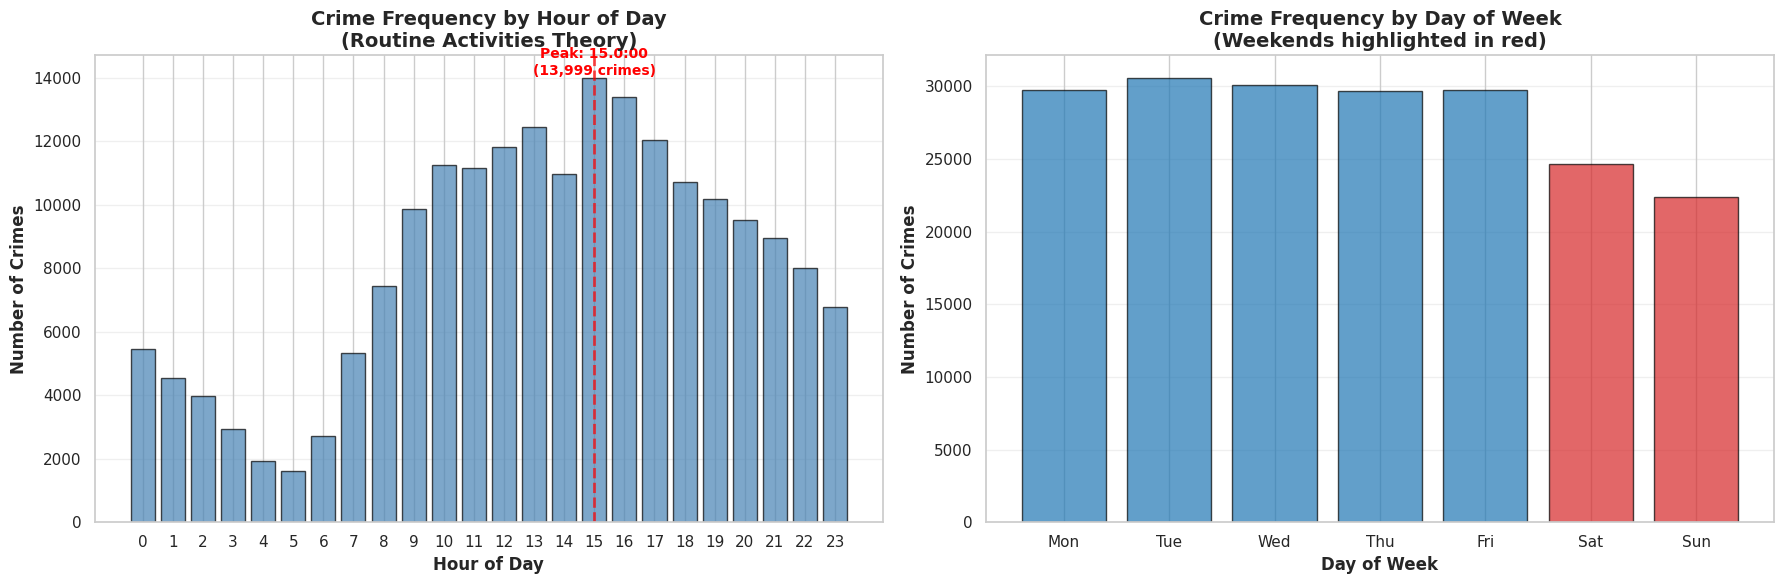

✓ Visualization saved: reports/figs/q1_temporal_patterns_1.png


In [58]:
# Question 1: When do crimes occur most frequently (time/day/month)?
# Theory link: Routine Activities Theory — crime increases when offender, target, and low guardianship converge
# Visualization 1: Crime frequency by hour of day and day of week

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: Hourly crime distribution
if 'hour' in df.columns:
    hourly_crimes = df.groupby('hour').size()
    axes[0].bar(hourly_crimes.index, hourly_crimes.values, color='steelblue', edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[0].set_title('Crime Frequency by Hour of Day\n(Routine Activities Theory)', fontsize=14, fontweight='bold')
    axes[0].set_xticks(range(0, 24))
    axes[0].grid(axis='y', alpha=0.3)

    # Add peak hour annotation
    peak_hour = hourly_crimes.idxmax()
    axes[0].axvline(x=peak_hour, color='red', linestyle='--', linewidth=2, alpha=0.7)
    axes[0].text(peak_hour, hourly_crimes.max(), f'Peak: {peak_hour}:00\n({hourly_crimes.max():,} crimes)',
                ha='center', va='bottom', fontsize=10, color='red', fontweight='bold')

# Right plot: Day of week distribution
if 'weekday' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    weekday_crimes = df['weekday'].value_counts().reindex(day_order)
    colors = ['#d62728' if day in ['Saturday', 'Sunday'] else '#1f77b4' for day in day_order]
    axes[1].bar(range(len(weekday_crimes)), weekday_crimes.values, color=colors, edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[1].set_title('Crime Frequency by Day of Week\n(Weekends highlighted in red)', fontsize=14, fontweight='bold')
    axes[1].set_xticks(range(len(weekday_crimes)))
    axes[1].set_xticklabels([day[:3] for day in day_order], rotation=0)
    axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q1_temporal_patterns_1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q1_temporal_patterns_1.png'}")


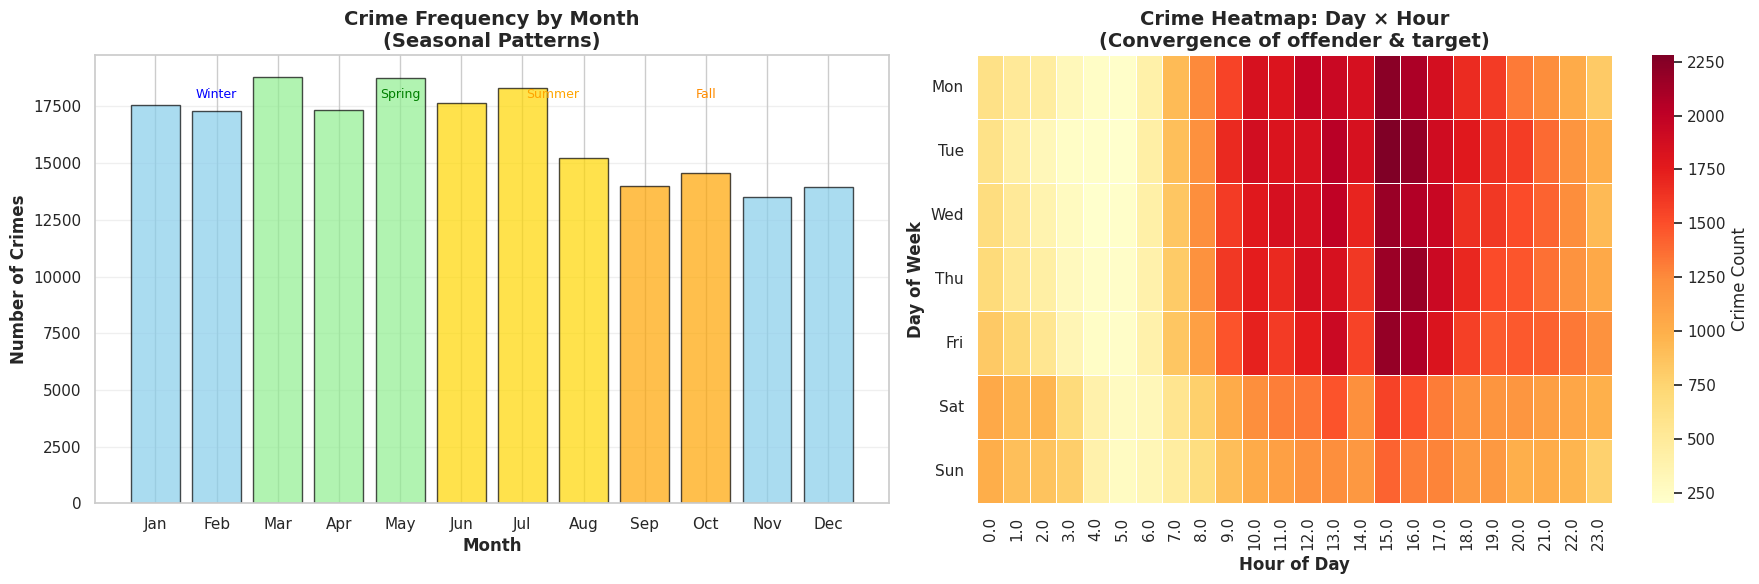

✓ Visualization saved: reports/figs/q1_temporal_patterns_2.png


In [28]:
# Question 1: When do crimes occur most frequently (time/day/month)?
# Theory link: Routine Activities Theory — crime increases when offender, target, and low guardianship converge
# Visualization 2: Monthly crime trends and seasonal patterns

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: Monthly crime distribution
if 'month' in df.columns:
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    monthly_crimes = df.groupby('month').size()

    # Color code by season
    season_colors = ['#87CEEB', '#87CEEB', '#90EE90', '#90EE90', '#90EE90',
                     '#FFD700', '#FFD700', '#FFD700', '#FFA500', '#FFA500', '#87CEEB', '#87CEEB']

    axes[0].bar(monthly_crimes.index, monthly_crimes.values, color=season_colors, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Month', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[0].set_title('Crime Frequency by Month\n(Seasonal Patterns)', fontsize=14, fontweight='bold')
    axes[0].set_xticks(range(1, 13))
    axes[0].set_xticklabels(month_names)
    axes[0].grid(axis='y', alpha=0.3)

    # Add season labels
    axes[0].text(2, monthly_crimes.max() * 0.95, 'Winter', ha='center', fontsize=9, color='blue')
    axes[0].text(5, monthly_crimes.max() * 0.95, 'Spring', ha='center', fontsize=9, color='green')
    axes[0].text(7.5, monthly_crimes.max() * 0.95, 'Summer', ha='center', fontsize=9, color='orange')
    axes[0].text(10, monthly_crimes.max() * 0.95, 'Fall', ha='center', fontsize=9, color='darkorange')

# Right plot: Heatmap of hour x day of week
if 'hour' in df.columns and 'weekday' in df.columns:
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_data = df.groupby(['weekday', 'hour']).size().unstack(fill_value=0)
    pivot_data = pivot_data.reindex(day_order)

    sns.heatmap(pivot_data, cmap='YlOrRd', annot=False, fmt='d', cbar_kws={'label': 'Crime Count'},
                ax=axes[1], linewidths=0.5)
    axes[1].set_xlabel('Hour of Day', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Day of Week', fontsize=12, fontweight='bold')
    axes[1].set_title('Crime Heatmap: Day × Hour\n(Convergence of offender & target)', fontsize=14, fontweight='bold')
    axes[1].set_yticklabels([day[:3] for day in day_order], rotation=0)

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q1_temporal_patterns_2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q1_temporal_patterns_2.png'}")


## RQ2. Which types of crimes are most common?
_Theory Link: Rational Choice Theory — theft is low-risk, high-reward → often most common crime._

_Author: Kevin Gomez_


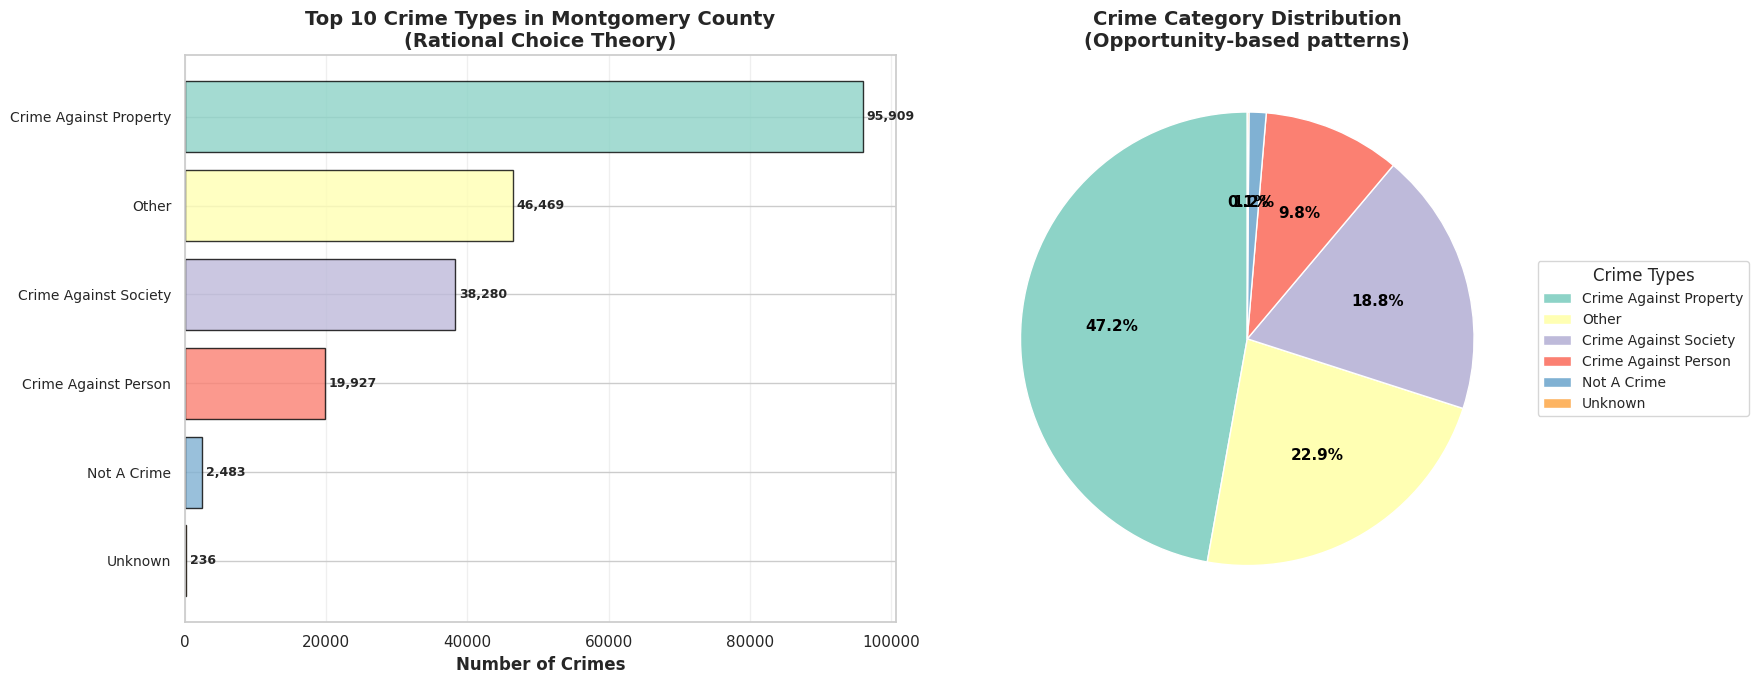

✓ Visualization saved: reports/figs/q2_crime_types_1.png


In [29]:
# Question 2: Which types of crimes are most common in Montgomery County?
# Theory link: Opportunity/Rational Choice Theory — theft/larceny typically dominates due to low risk and high opportunity
# Visualization 1: Top crime types distribution

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: Top 10 crime types by Primary Offense
if 'Primary Offense' in df.columns:
    top_crimes = df['Primary Offense'].value_counts().head(10)
    colors = plt.cm.Set3(range(len(top_crimes)))

    axes[0].barh(range(len(top_crimes)), top_crimes.values, color=colors, edgecolor='black', alpha=0.8)
    axes[0].set_yticks(range(len(top_crimes)))
    axes[0].set_yticklabels(top_crimes.index, fontsize=10)
    axes[0].set_xlabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[0].set_title('Top 10 Crime Types in Montgomery County\n(Rational Choice Theory)', fontsize=14, fontweight='bold')
    axes[0].invert_yaxis()
    axes[0].grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(top_crimes.values):
        axes[0].text(v + 500, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

# Right plot: Crime category proportions (pie chart)
if 'Primary Offense' in df.columns:
    crime_categories = df['Primary Offense'].value_counts()

    # Create pie chart with legend instead of labels
    colors_pie = plt.cm.Set3(range(len(crime_categories)))

    wedges, texts, autotexts = axes[1].pie(crime_categories.values, labels=None,
                                            autopct='%1.1f%%', startangle=90, colors=colors_pie,
                                            textprops={'fontsize': 11, 'fontweight': 'bold'})
    axes[1].set_title('Crime Category Distribution\n(Opportunity-based patterns)', fontsize=14, fontweight='bold')

    # Make percentage text more readable
    for autotext in autotexts:
        autotext.set_color('black')
        autotext.set_fontweight('bold')

    # Add legend to avoid text overlap
    axes[1].legend(wedges, crime_categories.index, title="Crime Types",
                  loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=10)

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q2_crime_types_1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q2_crime_types_1.png'}")


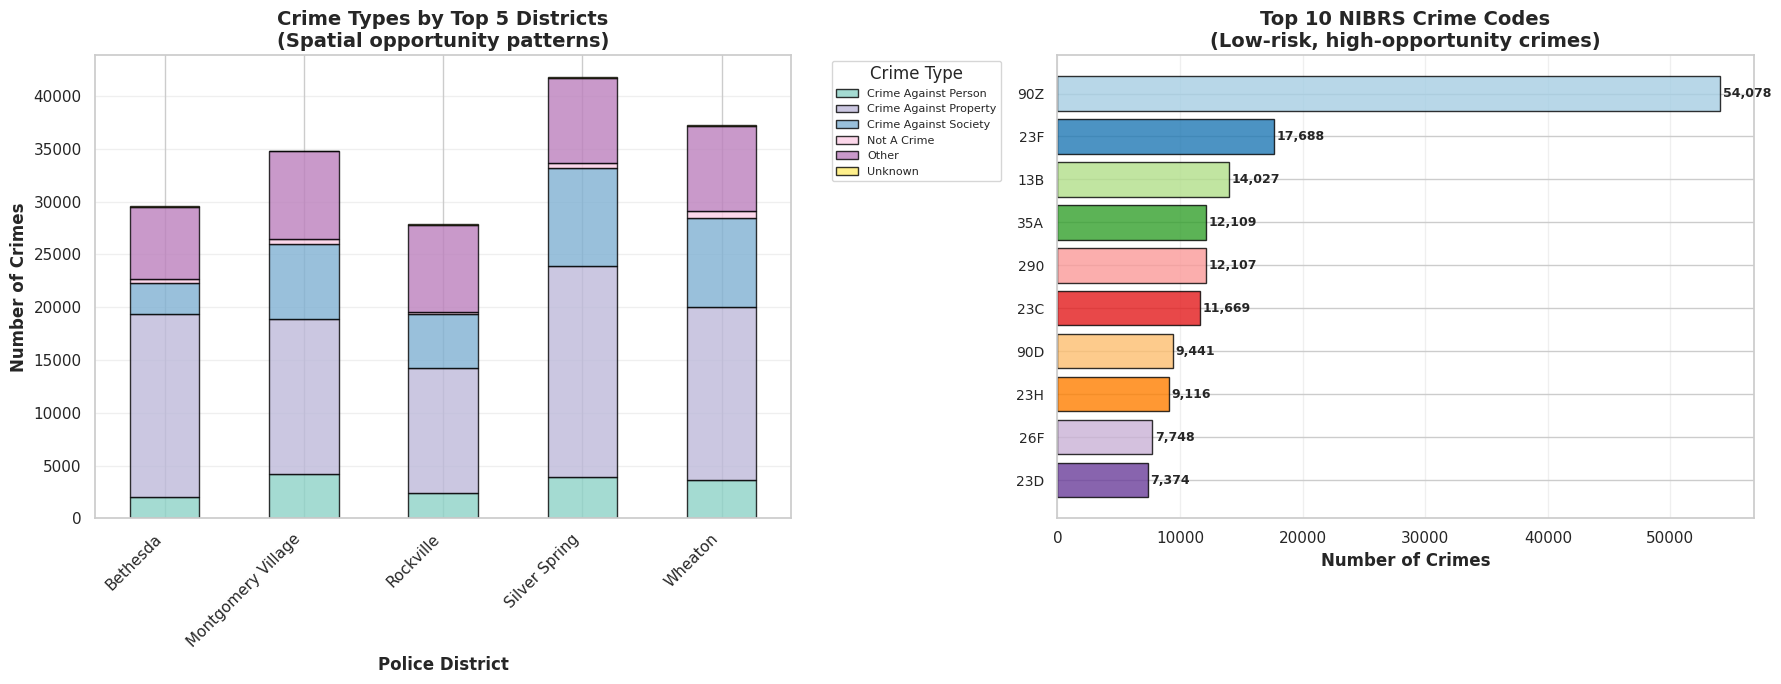

✓ Visualization saved: reports/figs/q2_crime_types_2.png


In [30]:
# Question 2: Which types of crimes are most common in Montgomery County?
# Theory link: Opportunity/Rational Choice Theory — theft/larceny typically dominates due to low risk and high opportunity
# Visualization 2: Crime types by district and NIBRS code analysis

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left plot: Crime types across top 5 districts
if 'District_Norm' in df.columns and 'Primary Offense' in df.columns:
    top_districts = df['District_Norm'].value_counts().head(5).index
    district_crime_data = df[df['District_Norm'].isin(top_districts)].groupby(['District_Norm', 'Primary Offense']).size().unstack(fill_value=0)

    district_crime_data.plot(kind='bar', stacked=True, ax=axes[0], colormap='Set3', edgecolor='black', alpha=0.8)
    axes[0].set_xlabel('Police District', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[0].set_title('Crime Types by Top 5 Districts\n(Spatial opportunity patterns)', fontsize=14, fontweight='bold')
    axes[0].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
    axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
    axes[0].grid(axis='y', alpha=0.3)

# Right plot: Top NIBRS codes
if 'NIBRS Code' in df.columns and 'Crime Name2' in df.columns:
    # Get top 10 NIBRS codes with their crime names
    nibrs_data = df.groupby(['NIBRS Code', 'Crime Name2']).size().reset_index(name='count')
    nibrs_summary = nibrs_data.groupby('NIBRS Code')['count'].sum().sort_values(ascending=False).head(10)

    colors_nibrs = plt.cm.Paired(range(len(nibrs_summary)))
    axes[1].barh(range(len(nibrs_summary)), nibrs_summary.values, color=colors_nibrs, edgecolor='black', alpha=0.8)
    axes[1].set_yticks(range(len(nibrs_summary)))
    axes[1].set_yticklabels(nibrs_summary.index, fontsize=10)
    axes[1].set_xlabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[1].set_title('Top 10 NIBRS Crime Codes\n(Low-risk, high-opportunity crimes)', fontsize=14, fontweight='bold')
    axes[1].invert_yaxis()
    axes[1].grid(axis='x', alpha=0.3)

    # Add value labels
    for i, v in enumerate(nibrs_summary.values):
        axes[1].text(v + 200, i, f'{v:,}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q2_crime_types_2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q2_crime_types_2.png'}")


## RQ3. Annual Trends (2018–2022)
_Theory Link: Strain Theory — social stress (e.g., COVID-19) can increase certain crimes._

_Author: Kevin Gomez_


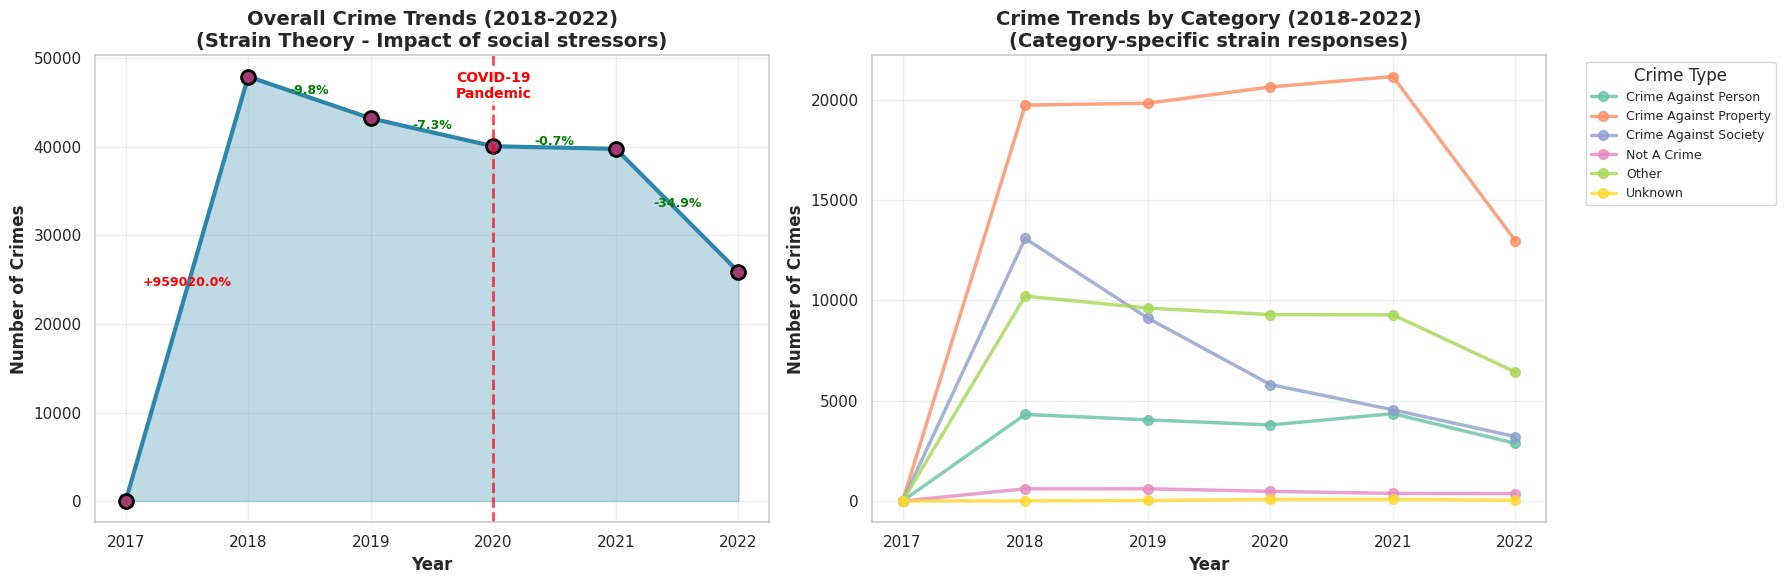

✓ Visualization saved: reports/figs/q3_yearly_trends_1.png


In [31]:
# Question 3: How have crime levels changed across the years 2018–2022?
# Theory link: Strain Theory — social stressors (e.g., pandemic) may cause increases in certain crime categories
# Visualization 1: Year-over-year crime trends

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left plot: Overall yearly crime trend
if 'year' in df.columns:
    yearly_crimes = df.groupby('year').size()

    axes[0].plot(yearly_crimes.index, yearly_crimes.values, marker='o', linewidth=3,
                markersize=10, color='#2E86AB', markerfacecolor='#A23B72', markeredgewidth=2, markeredgecolor='black')
    axes[0].fill_between(yearly_crimes.index, yearly_crimes.values, alpha=0.3, color='#2E86AB')
    axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[0].set_title('Overall Crime Trends (2018-2022)\n(Strain Theory - Impact of social stressors)', fontsize=14, fontweight='bold')
    axes[0].set_xticks(yearly_crimes.index)
    axes[0].grid(True, alpha=0.3)

    # Highlight 2020 (pandemic year)
    pandemic_year = 2020
    if pandemic_year in yearly_crimes.index:
        axes[0].axvline(x=pandemic_year, color='red', linestyle='--', linewidth=2, alpha=0.7)
        axes[0].text(pandemic_year, yearly_crimes.max() * 0.95, 'COVID-19\nPandemic',
                    ha='center', fontsize=10, color='red', fontweight='bold',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    # Add percentage change annotations
    for i in range(len(yearly_crimes) - 1):
        year_curr = yearly_crimes.index[i]
        year_next = yearly_crimes.index[i + 1]
        change_pct = ((yearly_crimes.iloc[i + 1] - yearly_crimes.iloc[i]) / yearly_crimes.iloc[i]) * 100
        mid_x = (year_curr + year_next) / 2
        mid_y = (yearly_crimes.iloc[i] + yearly_crimes.iloc[i + 1]) / 2
        color = 'green' if change_pct < 0 else 'red'
        axes[0].text(mid_x, mid_y, f'{change_pct:+.1f}%', ha='center', va='bottom',
                    fontsize=9, color=color, fontweight='bold')

# Right plot: Crime trends by category
if 'year' in df.columns and 'Primary Offense' in df.columns:
    crime_by_year = df.groupby(['year', 'Primary Offense']).size().unstack(fill_value=0)

    crime_by_year.plot(kind='line', ax=axes[1], marker='o', linewidth=2.5, markersize=7, alpha=0.8)
    axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[1].set_title('Crime Trends by Category (2018-2022)\n(Category-specific strain responses)', fontsize=14, fontweight='bold')
    axes[1].legend(title='Crime Type', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(crime_by_year.index)

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q3_yearly_trends_1.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q3_yearly_trends_1.png'}")


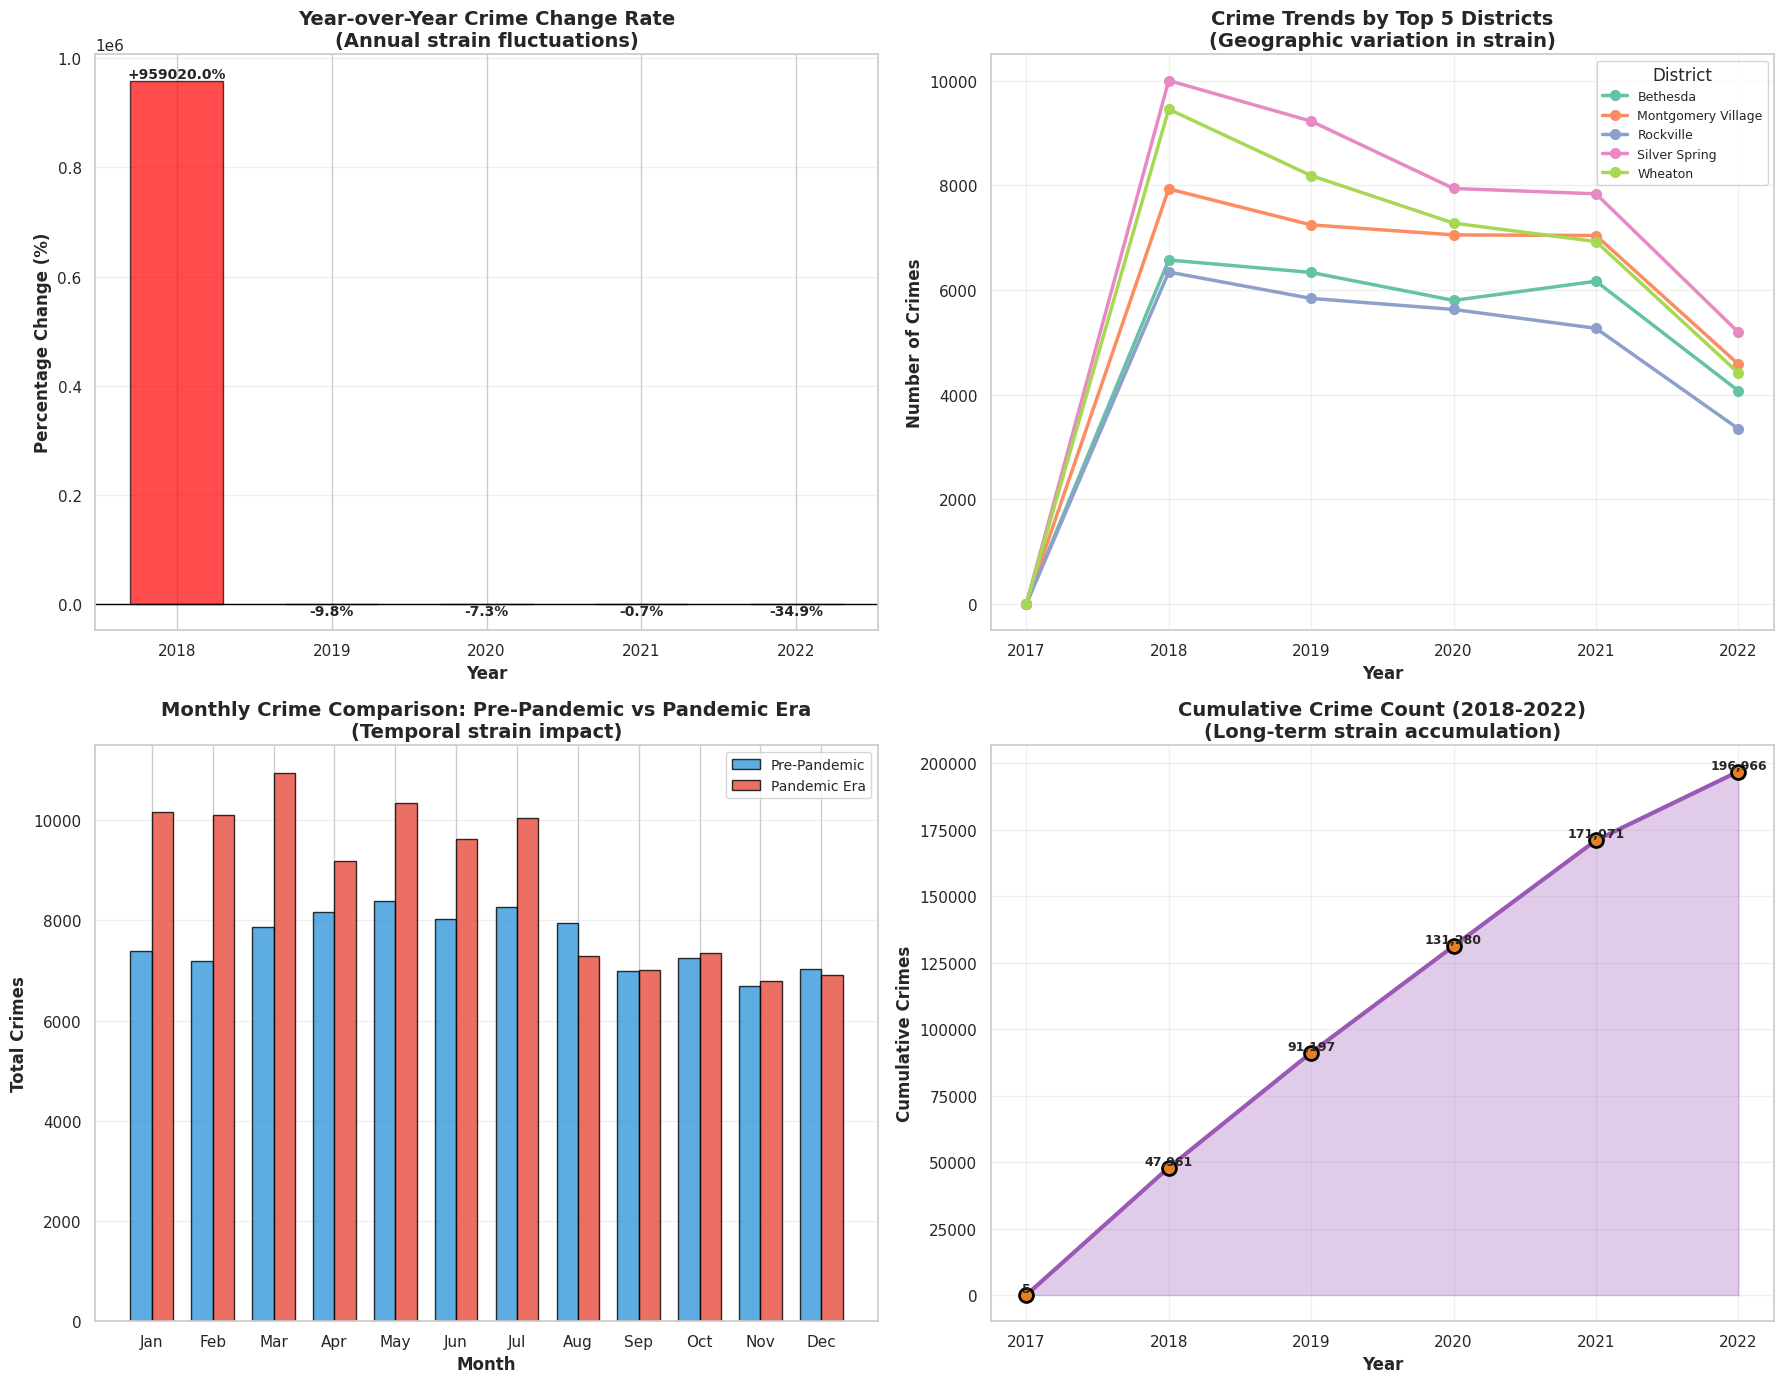

✓ Visualization saved: reports/figs/q3_yearly_trends_2.png


In [32]:
# Question 3: How have crime levels changed across the years 2018–2022?
# Theory link: Strain Theory — social stressors (e.g., pandemic) may cause increases in certain crime categories
# Visualization 2: District-level changes and comparative analysis

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
axes = axes.flatten()

# Plot 1: Year-over-year percentage change
if 'year' in df.columns:
    yearly_crimes = df.groupby('year').size()
    pct_changes = yearly_crimes.pct_change() * 100

    colors = ['green' if x < 0 else 'red' for x in pct_changes.values[1:]]
    axes[0].bar(pct_changes.index[1:], pct_changes.values[1:], color=colors, edgecolor='black', alpha=0.7, width=0.6)
    axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1)
    axes[0].set_xlabel('Year', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Percentage Change (%)', fontsize=12, fontweight='bold')
    axes[0].set_title('Year-over-Year Crime Change Rate\n(Annual strain fluctuations)', fontsize=14, fontweight='bold')
    axes[0].grid(axis='y', alpha=0.3)

    # Add value labels
    for i, (year, val) in enumerate(zip(pct_changes.index[1:], pct_changes.values[1:])):
        axes[0].text(year, val, f'{val:+.1f}%', ha='center', va='bottom' if val > 0 else 'top',
                    fontsize=10, fontweight='bold')

# Plot 2: Top 5 districts crime trends
if 'year' in df.columns and 'District_Norm' in df.columns:
    top_5_districts = df['District_Norm'].value_counts().head(5).index
    district_yearly = df[df['District_Norm'].isin(top_5_districts)].groupby(['year', 'District_Norm']).size().unstack(fill_value=0)

    district_yearly.plot(kind='line', ax=axes[1], marker='o', linewidth=2.5, markersize=7)
    axes[1].set_xlabel('Year', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Number of Crimes', fontsize=12, fontweight='bold')
    axes[1].set_title('Crime Trends by Top 5 Districts\n(Geographic variation in strain)', fontsize=14, fontweight='bold')
    axes[1].legend(title='District', loc='best', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    axes[1].set_xticks(district_yearly.index)

# Plot 3: Monthly aggregated comparison (pre vs post pandemic)
if 'year' in df.columns and 'month' in df.columns:
    df['period'] = df['year'].apply(lambda x: 'Pre-Pandemic (2018-2019)' if x < 2020 else 'Pandemic Era (2020-2022)')
    period_monthly = df.groupby(['period', 'month']).size().unstack(fill_value=0)

    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    x = np.arange(len(month_names))
    width = 0.35

    if 'Pre-Pandemic (2018-2019)' in period_monthly.index:
        axes[2].bar(x - width/2, period_monthly.loc['Pre-Pandemic (2018-2019)'].values, width,
                   label='Pre-Pandemic', color='#3498db', edgecolor='black', alpha=0.8)
    if 'Pandemic Era (2020-2022)' in period_monthly.index:
        axes[2].bar(x + width/2, period_monthly.loc['Pandemic Era (2020-2022)'].values, width,
                   label='Pandemic Era', color='#e74c3c', edgecolor='black', alpha=0.8)

    axes[2].set_xlabel('Month', fontsize=12, fontweight='bold')
    axes[2].set_ylabel('Total Crimes', fontsize=12, fontweight='bold')
    axes[2].set_title('Monthly Crime Comparison: Pre-Pandemic vs Pandemic Era\n(Temporal strain impact)', fontsize=14, fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels(month_names)
    axes[2].legend(loc='best', fontsize=10)
    axes[2].grid(axis='y', alpha=0.3)

# Plot 4: Cumulative crime comparison
if 'year' in df.columns:
    yearly_crimes = df.groupby('year').size()
    cumulative = yearly_crimes.cumsum()

    axes[3].plot(cumulative.index, cumulative.values, marker='o', linewidth=3,
                markersize=10, color='#9B59B6', markerfacecolor='#E67E22', markeredgewidth=2, markeredgecolor='black')
    axes[3].fill_between(cumulative.index, cumulative.values, alpha=0.3, color='#9B59B6')
    axes[3].set_xlabel('Year', fontsize=12, fontweight='bold')
    axes[3].set_ylabel('Cumulative Crimes', fontsize=12, fontweight='bold')
    axes[3].set_title('Cumulative Crime Count (2018-2022)\n(Long-term strain accumulation)', fontsize=14, fontweight='bold')
    axes[3].set_xticks(cumulative.index)
    axes[3].grid(True, alpha=0.3)

    # Add cumulative labels
    for year, count in zip(cumulative.index, cumulative.values):
        axes[3].text(year, count, f'{count:,}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR_FIGS / 'q3_yearly_trends_2.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Visualization saved: {OUT_DIR_FIGS / 'q3_yearly_trends_2.png'}")


## RQ4. Which cities report the highest crime?
_Theory Link: Social Disorganization Theory — high-density, high-mobility areas show more crime._

_Author: Hasini Dilhara_


In [33]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'City': 'city',
})

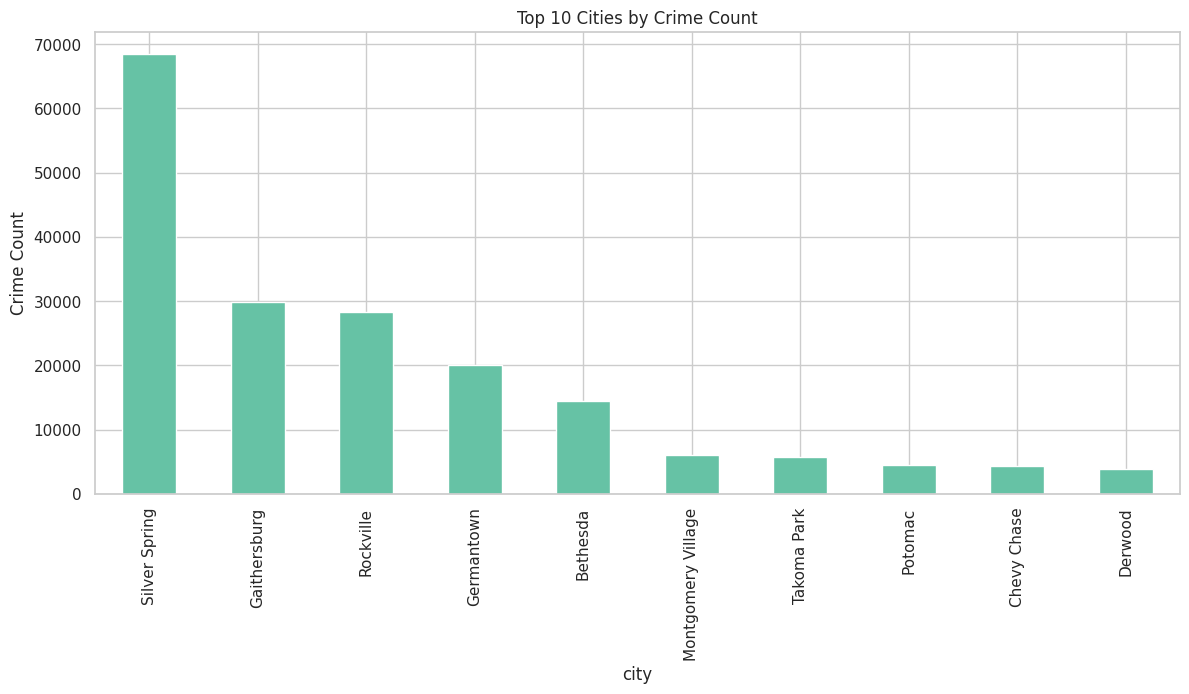

In [34]:
plt.figure(figsize=(14,6))
df['city'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Cities by Crime Count")
plt.ylabel("Crime Count")
plt.show()

## RQ5. Where are the geographic crime hotspots?
_Theory link: Environmental Criminology / Hotspot Theory — crime clusters in predictable high-activity zones._

_Author: Hasini Dilhara_


In [38]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'lat': 'Latitude',
    'lon': 'Longitude',
})

In [40]:
fig = px.density_mapbox(
    df, lat='Latitude', lon='Longitude',
    radius=10, zoom=9,
    mapbox_style='carto-positron'
)
fig.show()

## RQ6. ⁠How does location type (residential, commercial, public) influence crime occurrence?
_Theory Links:_
- _⁠Rational Choice Theory — property crime near commercial/transit zones._
- ⁠_Feminist Criminology — gender-based crime concentrated in private/domestic spaces._

_Author: Sanjeewa Silva_


In [41]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Place': 'place',
})

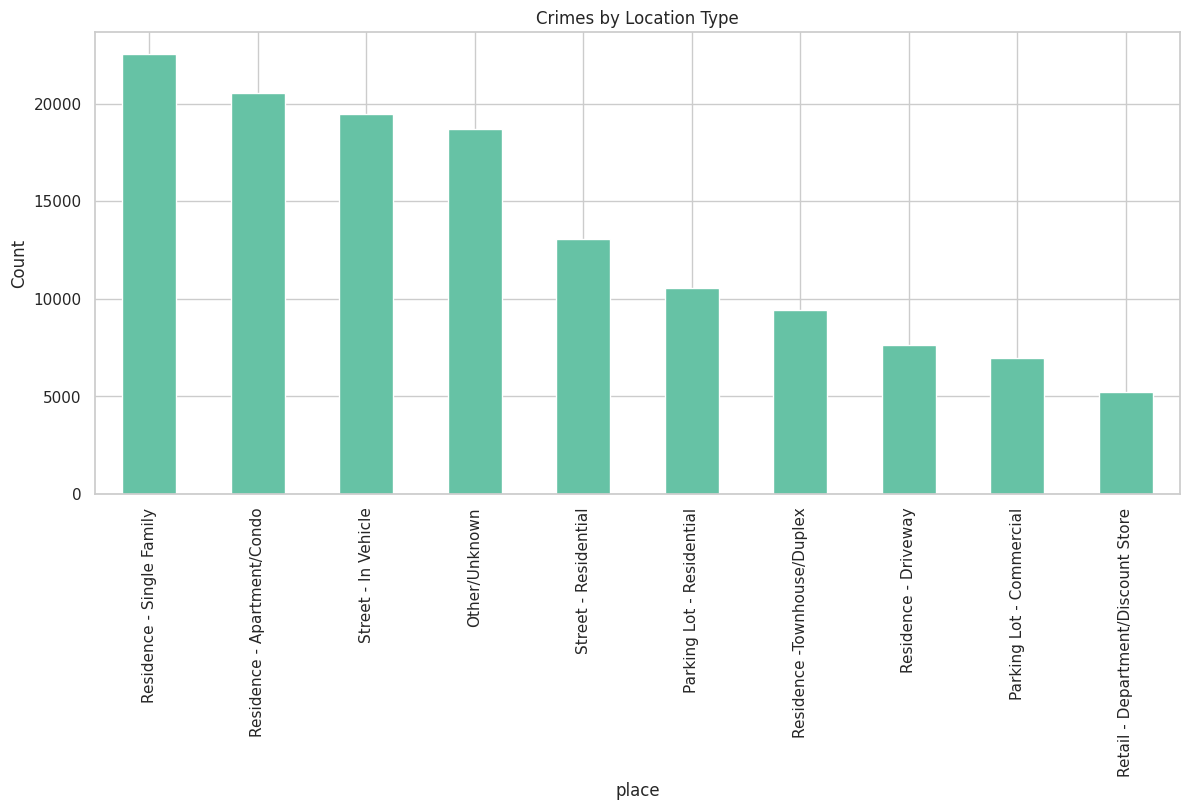

In [42]:
plt.figure(figsize=(14,6))
df['place'].value_counts().head(10).plot(kind='bar')
plt.title("Crimes by Location Type")
plt.ylabel("Count")
plt.show()

## RQ7. ⁠Which police districts handle the highest number of incidents?
_Theory Link: Hotspot + Social Disorganization — districts with more density/commercial areas have higher workload._

_Author: Sanjeewa Silva_


In [43]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Police District Number': 'police_district_number',
})

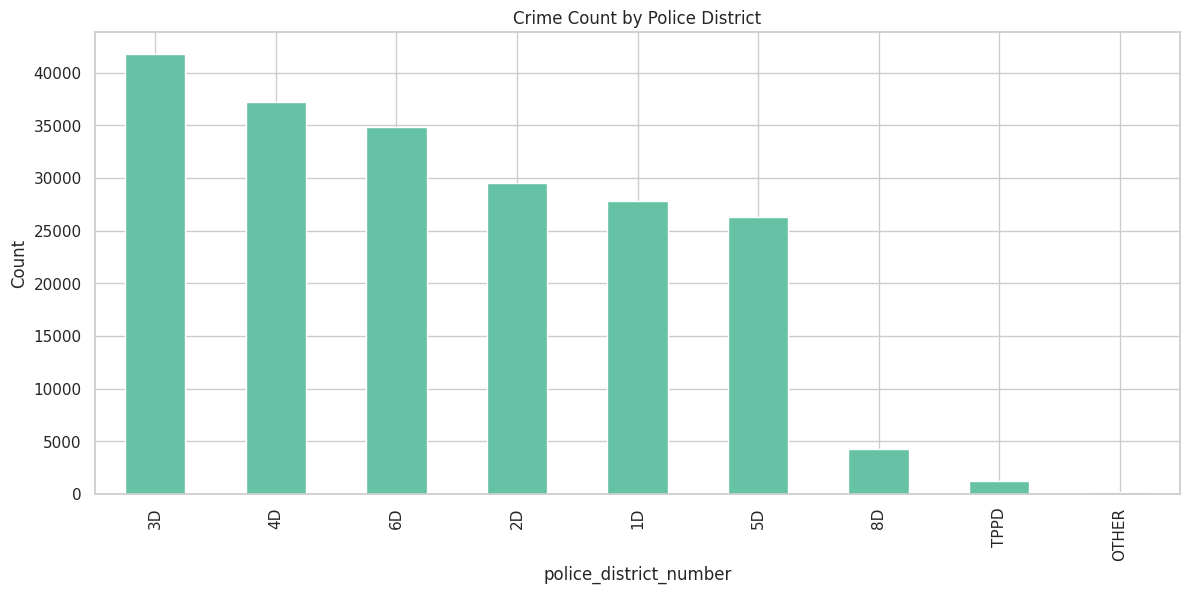

In [44]:
plt.figure(figsize=(14,6))
df['police_district_number'].value_counts().plot(kind='bar')
plt.title("Crime Count by Police District")
plt.ylabel("Count")
plt.show()

## RQ8. ⁠How does crime type vary by time of day?
_Theory Link: Routine Activities Theory — crime types follow human activity cycles._

_Author: Diyath Sahan Rajapakshe_


In [56]:
df = df.rename(columns={
    "Crime Name1": "crime_name1",
    "Crime Name2": "crime_name2",
    "Crime Name3": "crime_name3"
})

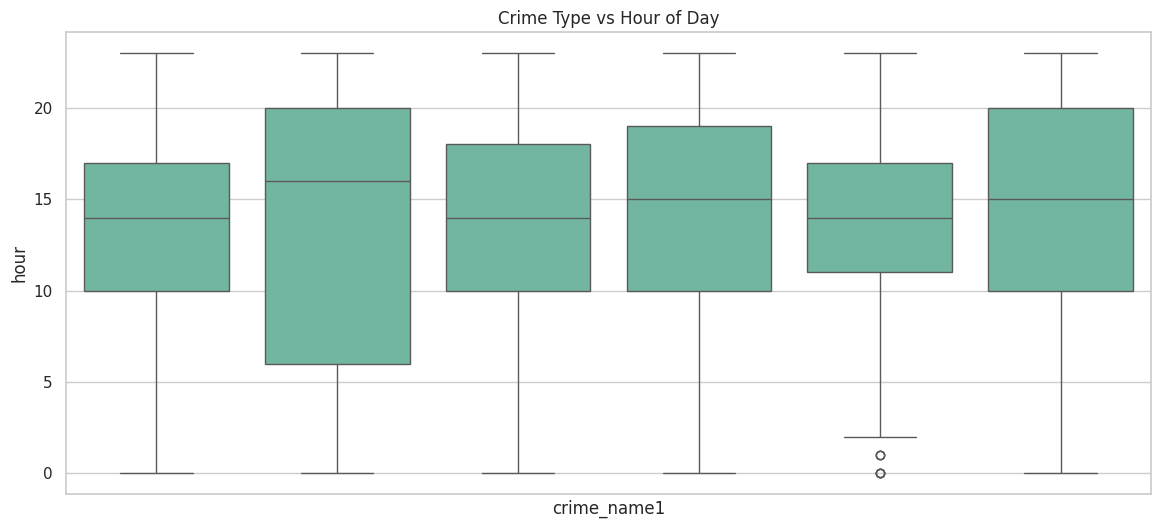

In [57]:
plt.figure(figsize=(14,6))
sns.boxplot(x='crime_name1', y='hour', data=df)
plt.xticks([], [])  # hide labels if too many values
plt.title("Crime Type vs Hour of Day")
plt.show()

## RQ9. ⁠How many victims are typically involved in each incident?
_Theory Link: NIBRS Victim Pattern Theory — most incidents involve one victim._

_Author: Diyath Sahan Rajapakshe_


In [46]:
# Standardize column names so the rest of the notebook works
df = df.rename(columns={
    'Victims': 'victims',
})

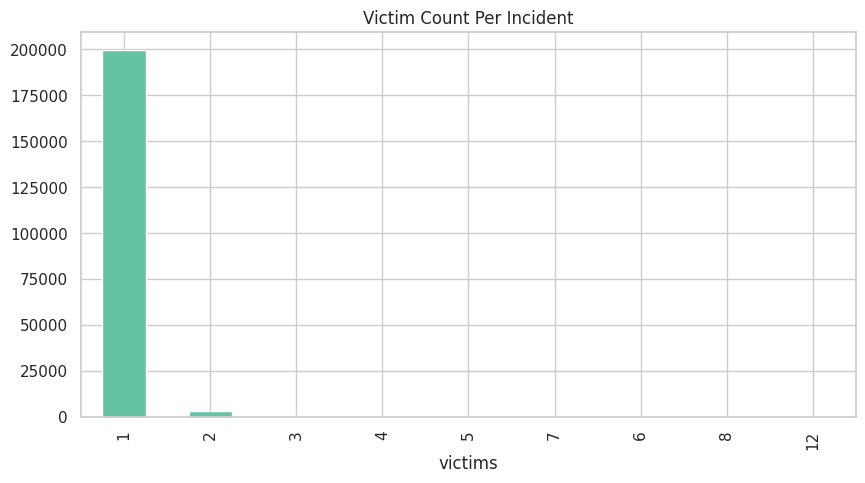

In [47]:
df['victims'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Victim Count Per Incident")
plt.show()

## RQ10. What seasonal or recurring patterns exist in crime occurrence?
_Theory link: Environmental Criminology — temperature, daylight, and social activity create seasonal crime cycles._

_Author: Diyath Sahan Rajapakshe_

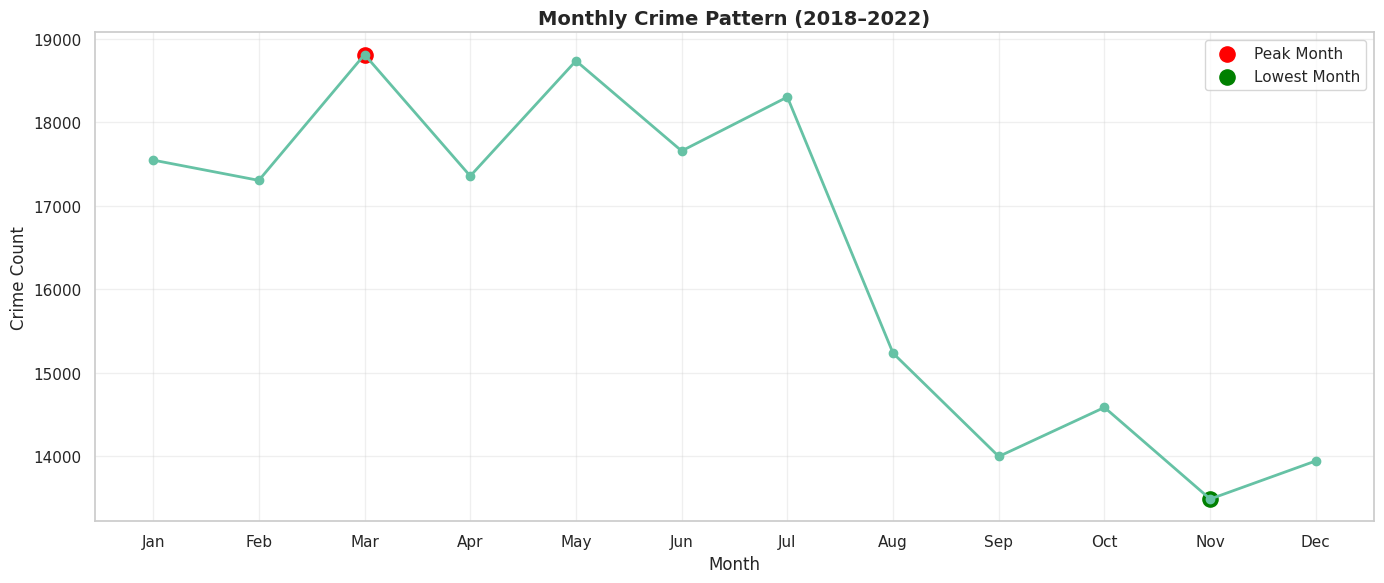

In [48]:
# Monthly Crime Pattern
plt.figure(figsize=(14, 6))
monthly_counts = df.groupby("month").size()

month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

plt.plot(monthly_counts.index, monthly_counts.values, marker="o", linestyle="-", linewidth=2)
plt.xticks(range(1, 13), month_names)
plt.title("Monthly Crime Pattern (2018–2022)", fontsize=14, fontweight="bold")
plt.ylabel("Crime Count")
plt.xlabel("Month")
plt.grid(alpha=0.3)

# Highlight max & min
max_month = monthly_counts.idxmax()
min_month = monthly_counts.idxmin()

plt.scatter(max_month, monthly_counts[max_month], color="red", s=120, label="Peak Month")
plt.scatter(min_month, monthly_counts[min_month], color="green", s=120, label="Lowest Month")
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# Create season column
def assign_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["season"] = df["month"].apply(assign_season)

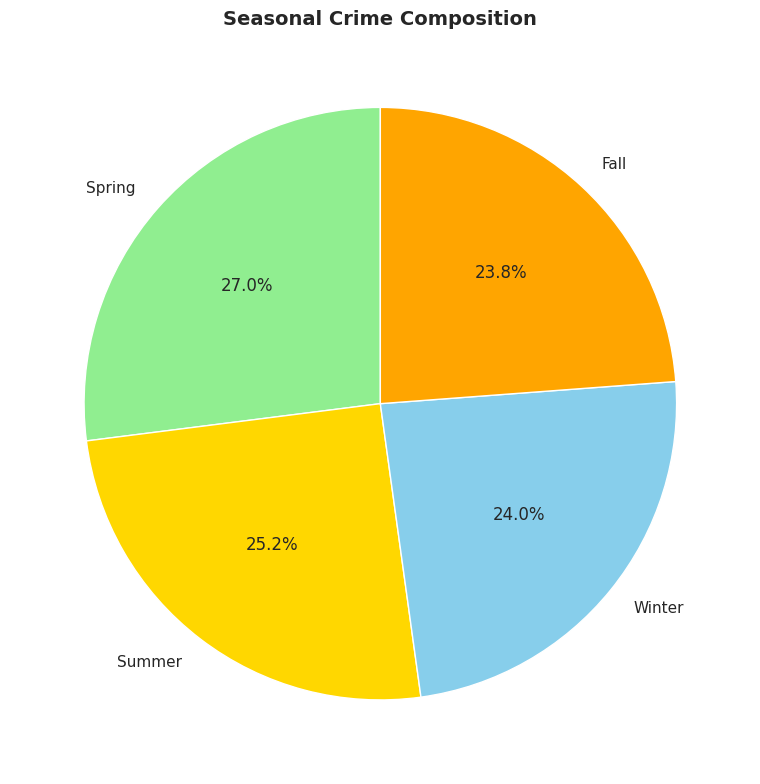

In [50]:
plt.figure(figsize=(8, 8))
season_counts = df["season"].value_counts()

colors = {"Winter": "#87CEEB", "Spring": "#90EE90", "Summer": "#FFD700", "Fall": "#FFA500"}
plt.pie(season_counts.values,
        labels=season_counts.index,
        autopct="%1.1f%%",
        colors=[colors[s] for s in season_counts.index],
        startangle=90)

plt.title("Seasonal Crime Composition", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

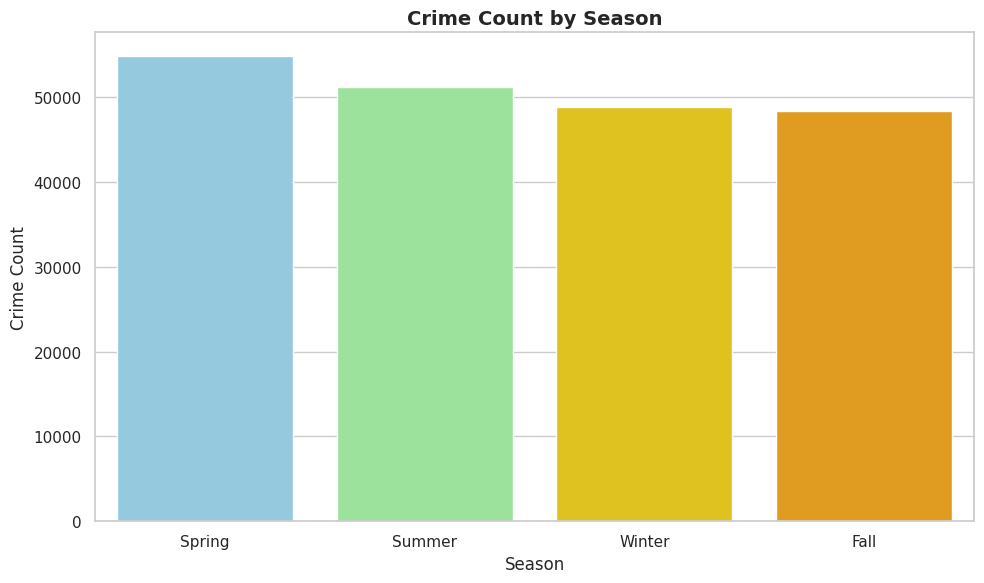

In [51]:
plt.figure(figsize=(10, 6))
sns.barplot(x=season_counts.index, y=season_counts.values, palette=list(colors.values()))
plt.title("Crime Count by Season", fontsize=14, fontweight="bold")
plt.ylabel("Crime Count")
plt.xlabel("Season")
plt.tight_layout()
plt.show()

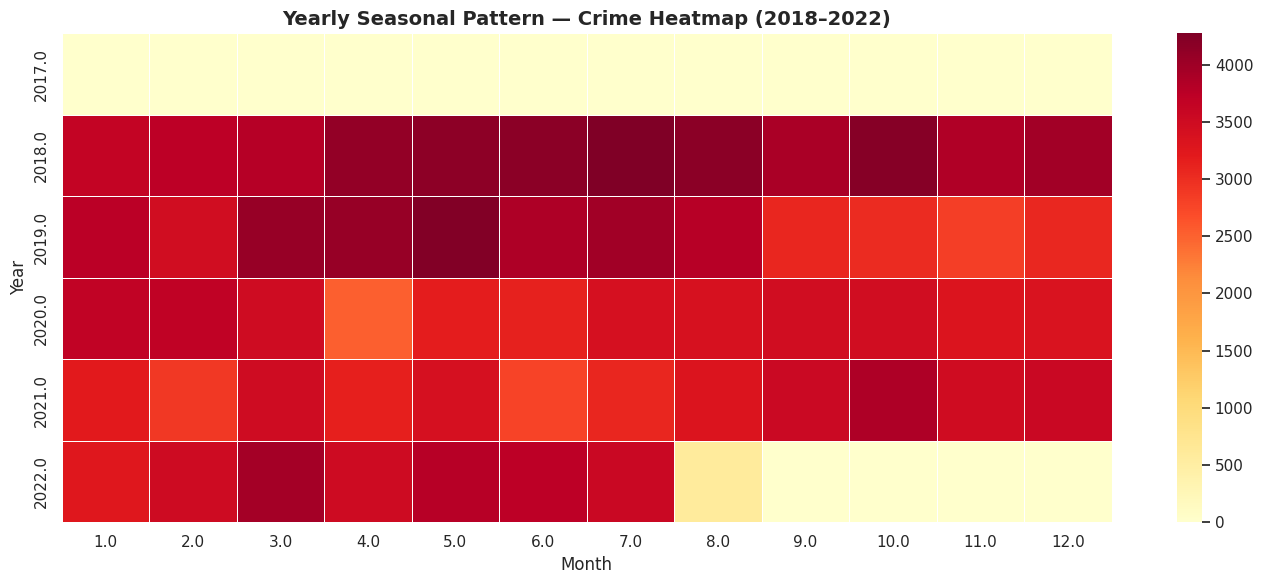

In [52]:
heatmap_table = df.groupby(["year", "month"]).size().unstack(fill_value=0)

plt.figure(figsize=(14, 6))
sns.heatmap(heatmap_table, cmap="YlOrRd", linewidths=0.5, annot=False)
plt.title("Yearly Seasonal Pattern — Crime Heatmap (2018–2022)", fontsize=14, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

In [53]:
df.to_csv("crime_clean_processed.csv", index=False)